<a href="https://colab.research.google.com/github/dr-dlr/ENOE/blob/main/EDA_Enoe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CAPÍTULO 5. ANÁLISIS EXPLORATORIO DE DATOS

Este documento contiene el Análisis Exploratorio de Datos (EDA) de la investigación sobre la precariedad salarial en Oaxaca de Juárez (mpio = 67), utilizando datos de la ENOE correspondientes al segundo trimestre de 2025. El análisis es de naturaleza estrictamente descriptiva y exploratoria; no se aplica ningún tipo de modelado predictivo o inferencia causal.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import os

# Configuración estética para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 300})

# Crear directorio para guardar figuras si no existe
if not os.path.exists('figuras_eda'):
    os.makedirs('figuras_eda')

# Diccionarios de mapeo para variables categóricas
map_sexo = {1: "Hombre", 2: "Mujer"}
map_estrato = {10: "Estrato bajo", 20: "Estrato medio bajo", 30: "Estrato medio alto", 40: "Estrato alto"}
map_edo_civil = {1: "Vive con su pareja", 2: "Está separado", 3: "Está divorciado", 4: "Está viudo", 5: "Está casado", 6: "Está soltero"}
map_pea = {1: "Población económicamente activa", 0: "Población no económicamente activa"}
map_tipo_empleado = {0: "No aplica", 1: "Subordinados y remunerados", 2: "Empleadores", 3: "Trabajadores por cuenta propia"}
map_tipo_empresa = {0: "No aplica", 1: "Micronegocios", 2: "Sin establecimientos", 3: "Con establecimientos", 4: "Pequeños establecimientos", 5: "Medianos establecimientos", 6: "Grandes establecimientos", 7: "Gobierno", 8: "Otros"}
map_emp_formal_inf = {0: "No aplica", 1: "Empleo informal", 2: "Empleo formal"}
map_tiene_jefe = {1: "Tiene un jefe o superior", 2: "No tiene un jefe o superior"}
map_target = {0: "Precariedad", 1: "Competitivo"}

## Auditoría y preparación del dataset

In [2]:
try:
    df = pd.read_csv('enoe_final.csv')
    print("Dataset cargado correctamente.")
except FileNotFoundError:
    print("Error: El archivo 'enoe_final.csv' no se encuentra. Asegúrate de haberlo subido al entorno.")
    # Crear un DataFrame dummy temporal solo para que el código no falle (eliminar en uso real)
    print("Generando datos simulados para permitir la ejecución de prueba...")
    np.random.seed(42)
    df = pd.DataFrame({
        'mpio': [67]*1363,
        'estrato': np.random.choice([10,20,30,40], 1363),
        'sexo': np.random.choice([1, 2], 1363),
        'edad': np.random.randint(18, 80, 1363),
        'edo_civil': np.random.choice([1,2,3,4,5,6], 1363),
        'pea_si_no': np.random.choice([0, 1], 1363),
        'tipo_empleado': np.random.choice([0,1,2,3], 1363),
        'tipo_empresa': np.random.choice([0,1,2,3,4,5,6,7,8], 1363),
        'anios_estudio': np.random.randint(0, 25, 1363),
        'hrs_trabajo': np.random.randint(0, 80, 1363),
        'ingreso': np.random.choice([0, 2000, 4500, 6000, 8000, 15000, 30000, np.nan], 1363, p=[0.2, 0.1, 0.2, 0.15, 0.15, 0.1, 0.05, 0.05]),
        'emp_formal_inf': np.random.choice([0,1,2], 1363),
        'tiene_jefe': np.random.choice([1,2], 1363)
    })

# Auditoría básica
print(f"\nNúmero de filas: {df.shape[0]}, Número de columnas: {df.shape[1]}")
display(df.info())
print("\nValores faltantes por variable:")
display(df.isnull().sum())

# Ignorar ingreso_clasificado si existe
if 'ingreso_clasificado' in df.columns:
    df = df.drop(columns=['ingreso_clasificado'])


Dataset cargado correctamente.

Número de filas: 1363, Número de columnas: 13
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1363 entries, 0 to 1362
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mpio            1363 non-null   int64  
 1   estrato         1363 non-null   int64  
 2   sexo            1363 non-null   int64  
 3   edad            1363 non-null   int64  
 4   edo_civil       1363 non-null   int64  
 5   pea_si_no       1363 non-null   int64  
 6   tipo_empleado   1363 non-null   int64  
 7   tipo_empresa    1363 non-null   int64  
 8   anios_estudio   1363 non-null   int64  
 9   hrs_trabajo     1363 non-null   int64  
 10  ingreso         1363 non-null   int64  
 11  emp_formal_inf  1363 non-null   int64  
 12  tiene_jefe      1334 non-null   float64
dtypes: float64(1), int64(12)
memory usage: 138.6 KB


None


Valores faltantes por variable:


,0
mpio,0
estrato,0
sexo,0
edad,0
edo_civil,0
pea_si_no,0
tipo_empleado,0
tipo_empresa,0
anios_estudio,0
hrs_trabajo,0


## 5.1 Construcción y distribución de la variable objetivo


### Construcción de la variable `target_precariedad`
- **Observaciones totales:** 1363
- **Ingresos iguales a cero:** 591
- **Ingresos positivos:** 772
- **Percentil 33 recalculado (ingresos positivos):** $6,000.00 pesos.
- **Clasificados en Precariedad:** 848 (62.2%)
- **Clasificados en Competitivo:** 515 (37.8%)


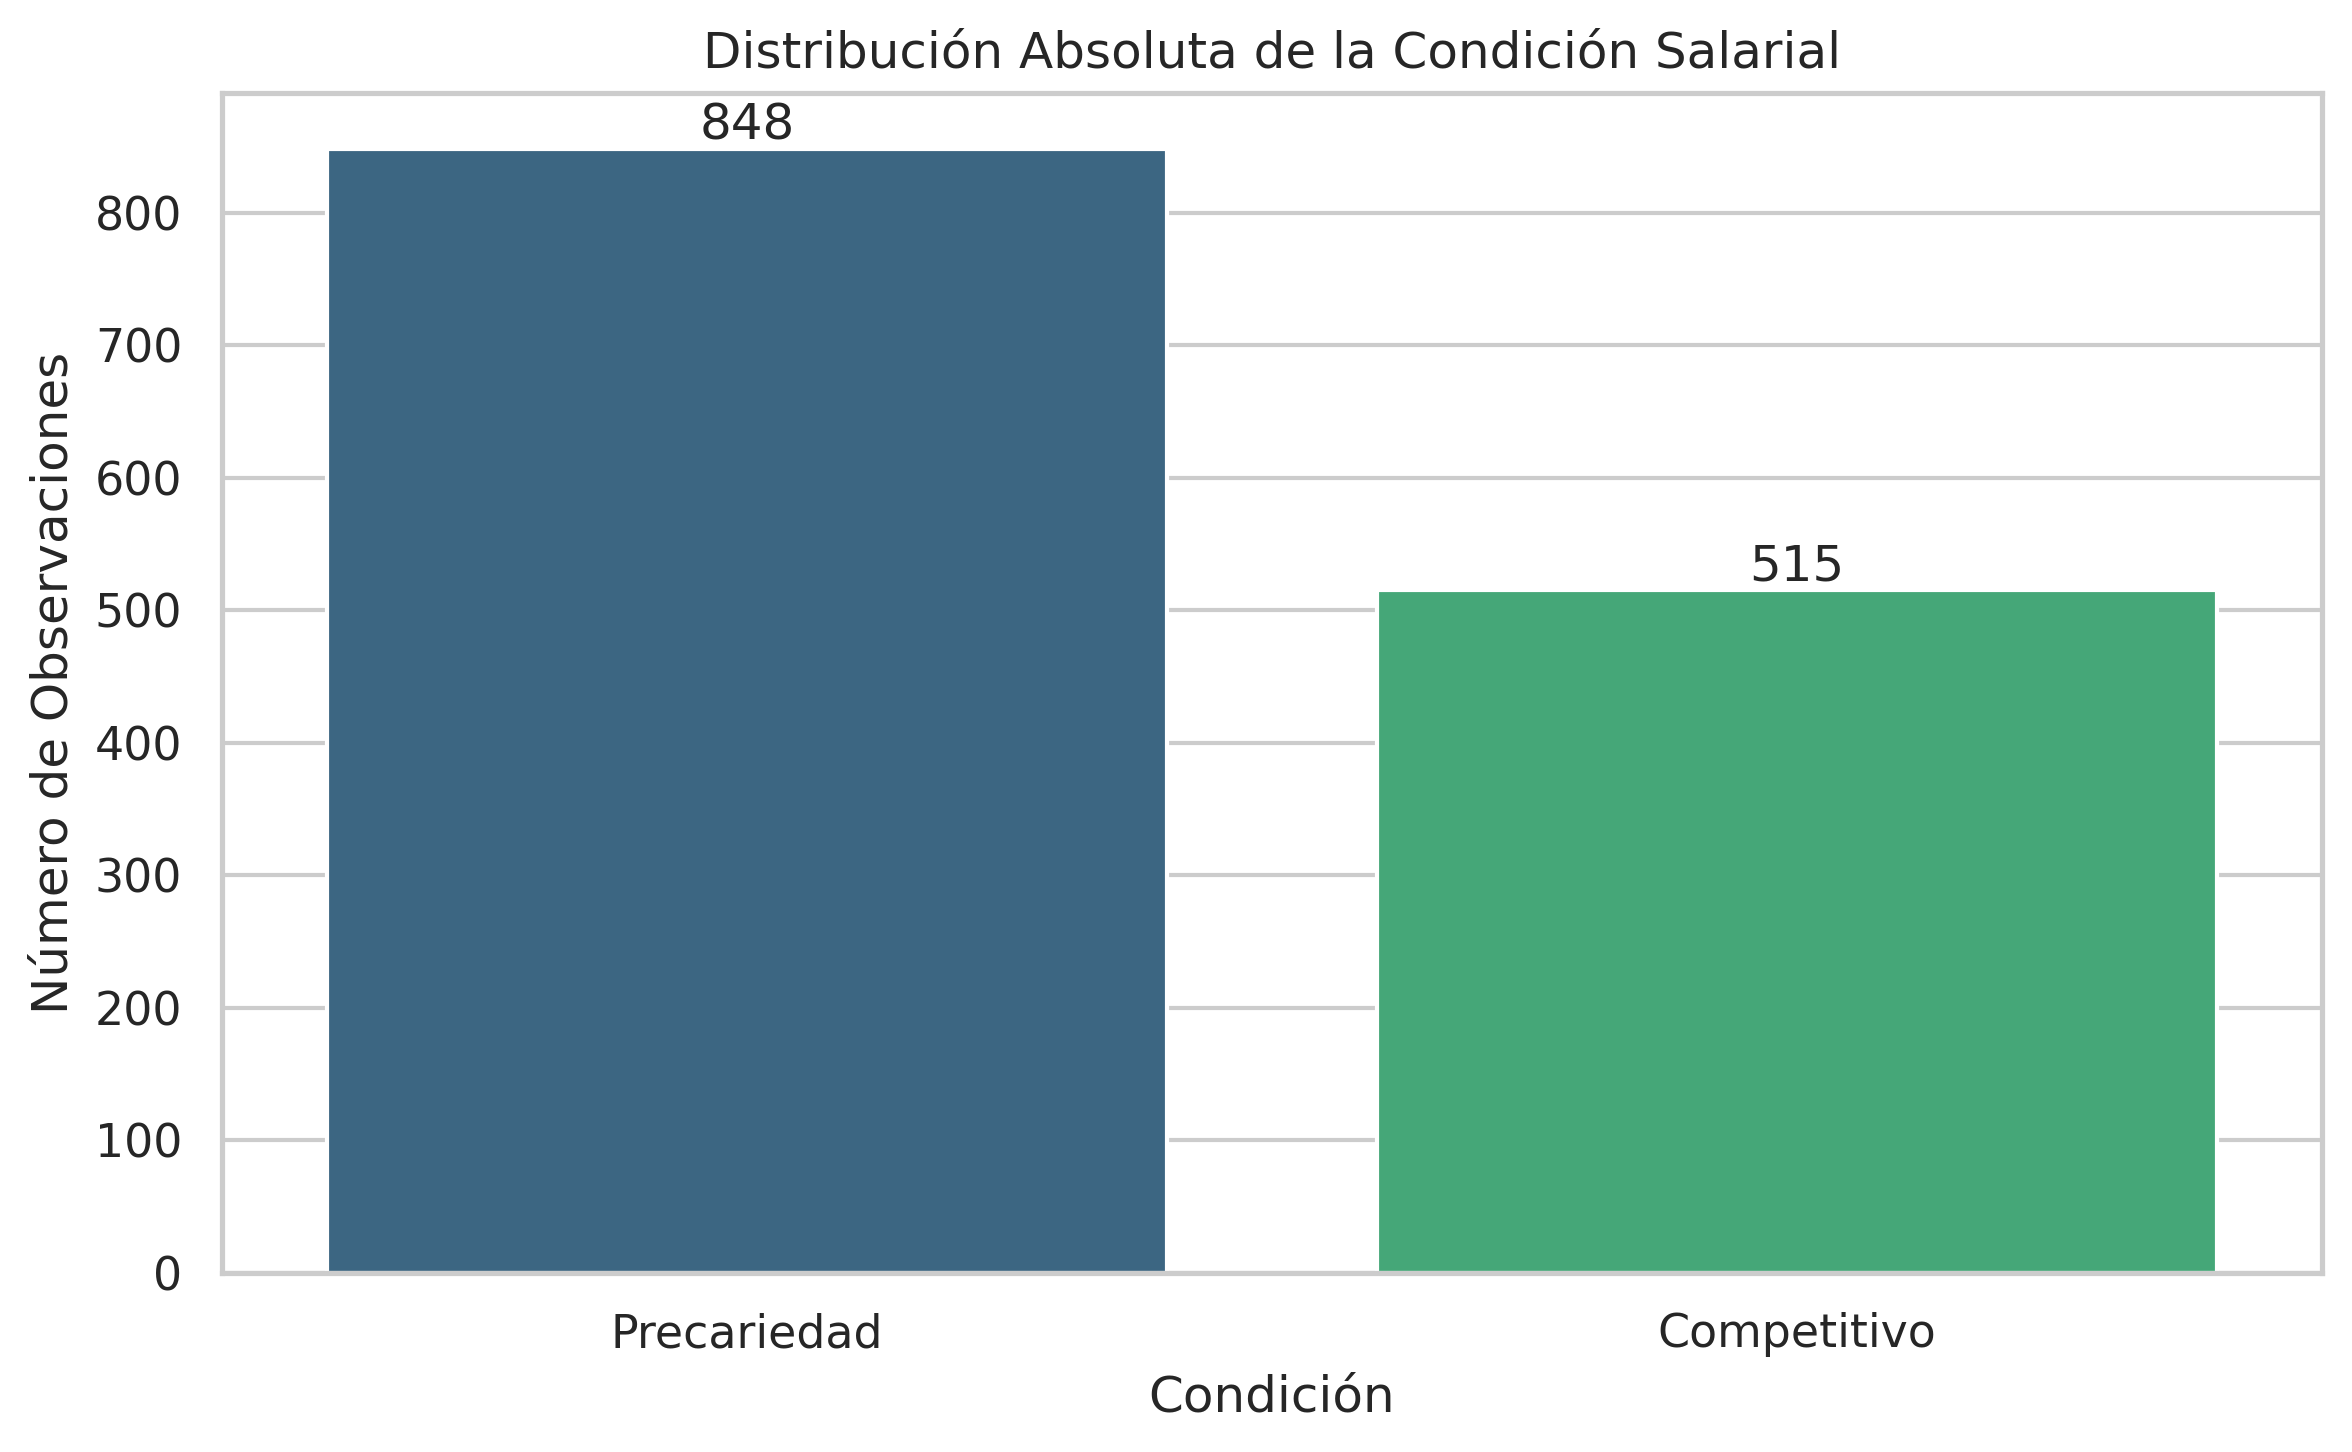

**Interpretación:** La figura ilustra la composición de la variable objetivo. El grupo en situación de precariedad concentra 848 observaciones, mientras que el grupo competitivo representa 515 observaciones. Esta distribución, calculada a partir del umbral de $6,000.00, define la estructura fundamental para las comparaciones bivariadas subsecuentes.

In [6]:
# Cálculo del percentil 33 sobre ingresos positivos
ingresos_positivos = df[df['ingreso'] > 0]['ingreso']
p33 = ingresos_positivos.quantile(0.33)

# Regla de clasificación
df['target_precariedad'] = np.where((df['ingreso'] <= p33) | (df['ingreso'].isna()), 0, 1)

# Estadísticas de la variable objetivo
total_obs = len(df)
ingresos_cero = len(df[df['ingreso'] == 0])
ingresos_pos = len(df[df['ingreso'] > 0])
precariedad_count = len(df[df['target_precariedad'] == 0])
competitivo_count = len(df[df['target_precariedad'] == 1])

display(Markdown(f"""
### Construcción de la variable `target_precariedad`
- **Observaciones totales:** {total_obs}
- **Ingresos iguales a cero:** {ingresos_cero}
- **Ingresos positivos:** {ingresos_pos}
- **Percentil 33 recalculado (ingresos positivos):** ${p33:,.2f} pesos.
- **Clasificados en Precariedad:** {precariedad_count} ({(precariedad_count/total_obs)*100:.1f}%)
- **Clasificados en Competitivo:** {competitivo_count} ({(competitivo_count/total_obs)*100:.1f}%)
"""))

# Gráfico 1: Distribución absoluta
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    x=df['target_precariedad'].map(map_target),
    order=["Precariedad", "Competitivo"],
    hue=df['target_precariedad'].map(map_target),
    palette='viridis',
    legend=False
)
plt.title('Distribución Absoluta de la Condición Salarial')
plt.xlabel('Condición')
plt.ylabel('Número de Observaciones')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.savefig('figuras_eda/fig_5_1_distribucion_absoluta.png')
plt.show()

display(Markdown(f"**Interpretación:** La figura ilustra la composición de la variable objetivo. El grupo en situación de precariedad concentra {precariedad_count} observaciones, mientras que el grupo competitivo representa {competitivo_count} observaciones. Esta distribución, calculada a partir del umbral de ${p33:,.2f}, define la estructura fundamental para las comparaciones bivariadas subsecuentes."))

## 5.2 Perfil sociodemográfico de la precariedad

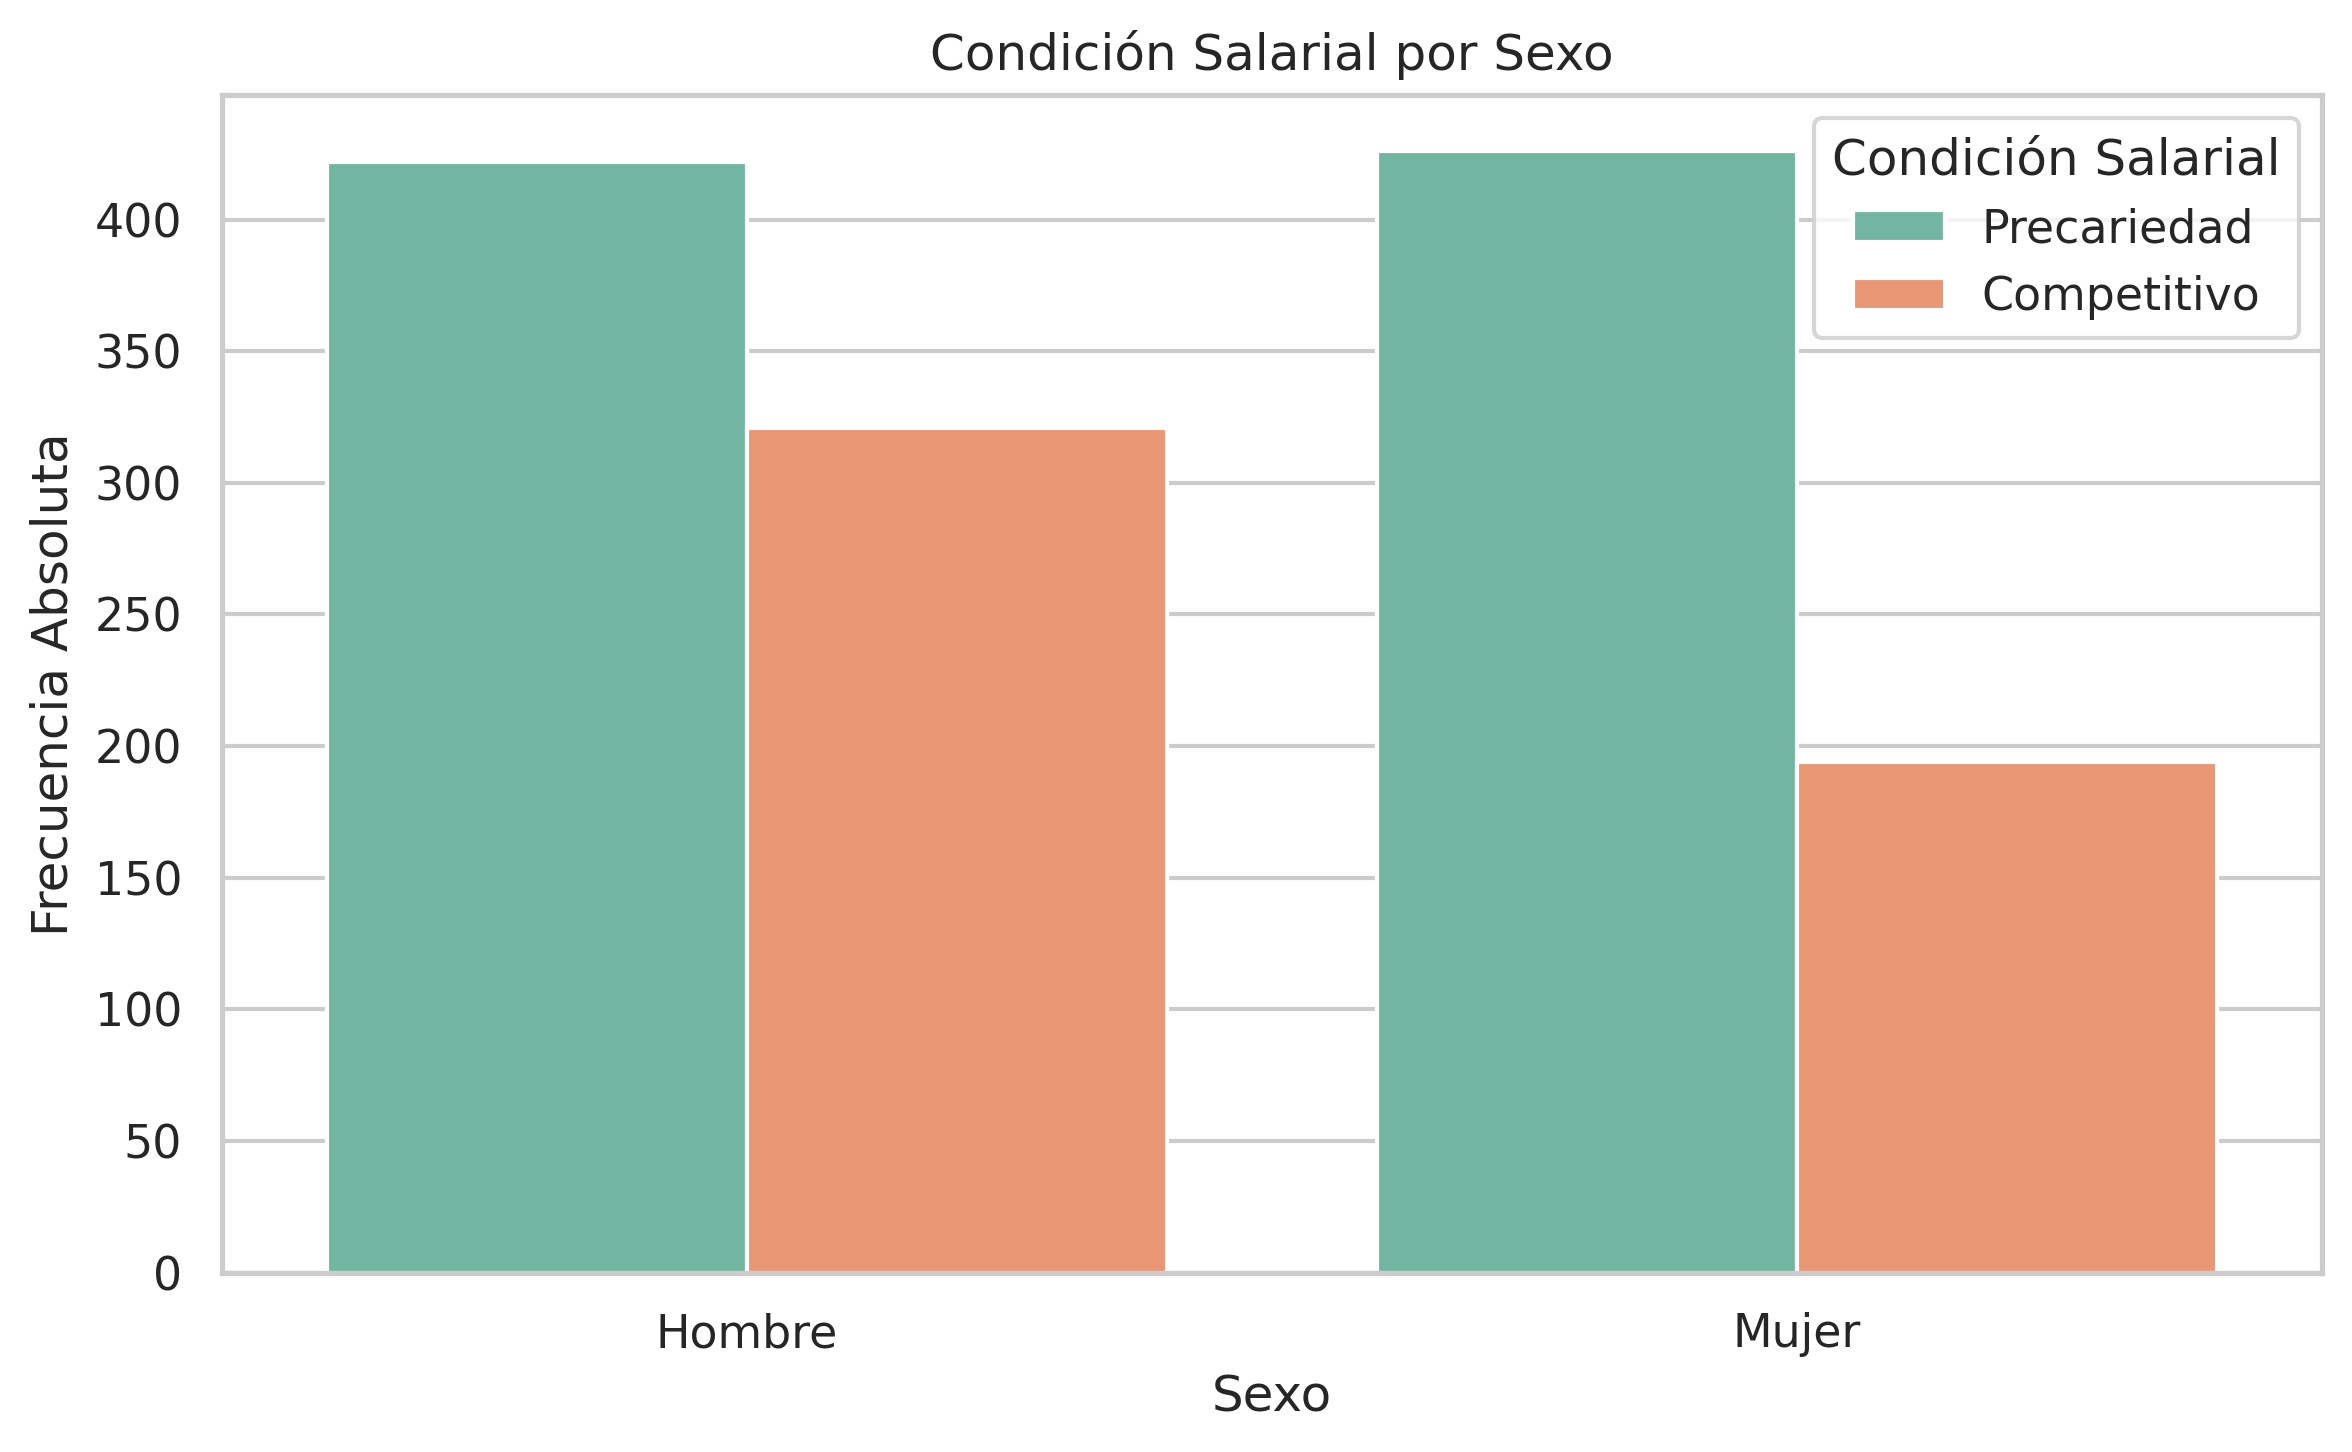

**Interpretación:** Al segmentar la muestra por sexo, los datos muestran que el 68.7% de las mujeres se encuentra clasificada en precariedad salarial, en contraste con el 56.8% de los hombres. Esta diferencia porcentual sugiere una asociación descriptiva que merece consideración analítica, evitando establecer relaciones causales directas.

In [4]:
# Preparar dataframe temporal con etiquetas legibles
df_plot = df.copy()
df_plot['sexo_etiq'] = df_plot['sexo'].map(map_sexo)
df_plot['target_etiq'] = df_plot['target_precariedad'].map(map_target)

# Gráfico por Sexo
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_plot, x='sexo_etiq', hue='target_etiq', palette='Set2')
plt.title('Condición Salarial por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Frecuencia Absoluta')
plt.legend(title='Condición Salarial')
plt.tight_layout()
plt.savefig('figuras_eda/fig_5_2_sexo.png')
plt.show()

# Cálculo dinámico
mujeres_precarias = len(df_plot[(df_plot['sexo_etiq'] == 'Mujer') & (df_plot['target_etiq'] == 'Precariedad')])
total_mujeres = len(df_plot[df_plot['sexo_etiq'] == 'Mujer'])
prop_mujeres = (mujeres_precarias/total_mujeres)*100 if total_mujeres > 0 else 0

hombres_precarios = len(df_plot[(df_plot['sexo_etiq'] == 'Hombre') & (df_plot['target_etiq'] == 'Precariedad')])
total_hombres = len(df_plot[df_plot['sexo_etiq'] == 'Hombre'])
prop_hombres = (hombres_precarios/total_hombres)*100 if total_hombres > 0 else 0

display(Markdown(f"**Interpretación:** Al segmentar la muestra por sexo, los datos muestran que el {prop_mujeres:.1f}% de las mujeres se encuentra clasificada en precariedad salarial, en contraste con el {prop_hombres:.1f}% de los hombres. Esta diferencia porcentual sugiere una asociación descriptiva que merece consideración analítica, evitando establecer relaciones causales directas."))


### Edad
Análisis de la distribución etaria según la condición salarial.

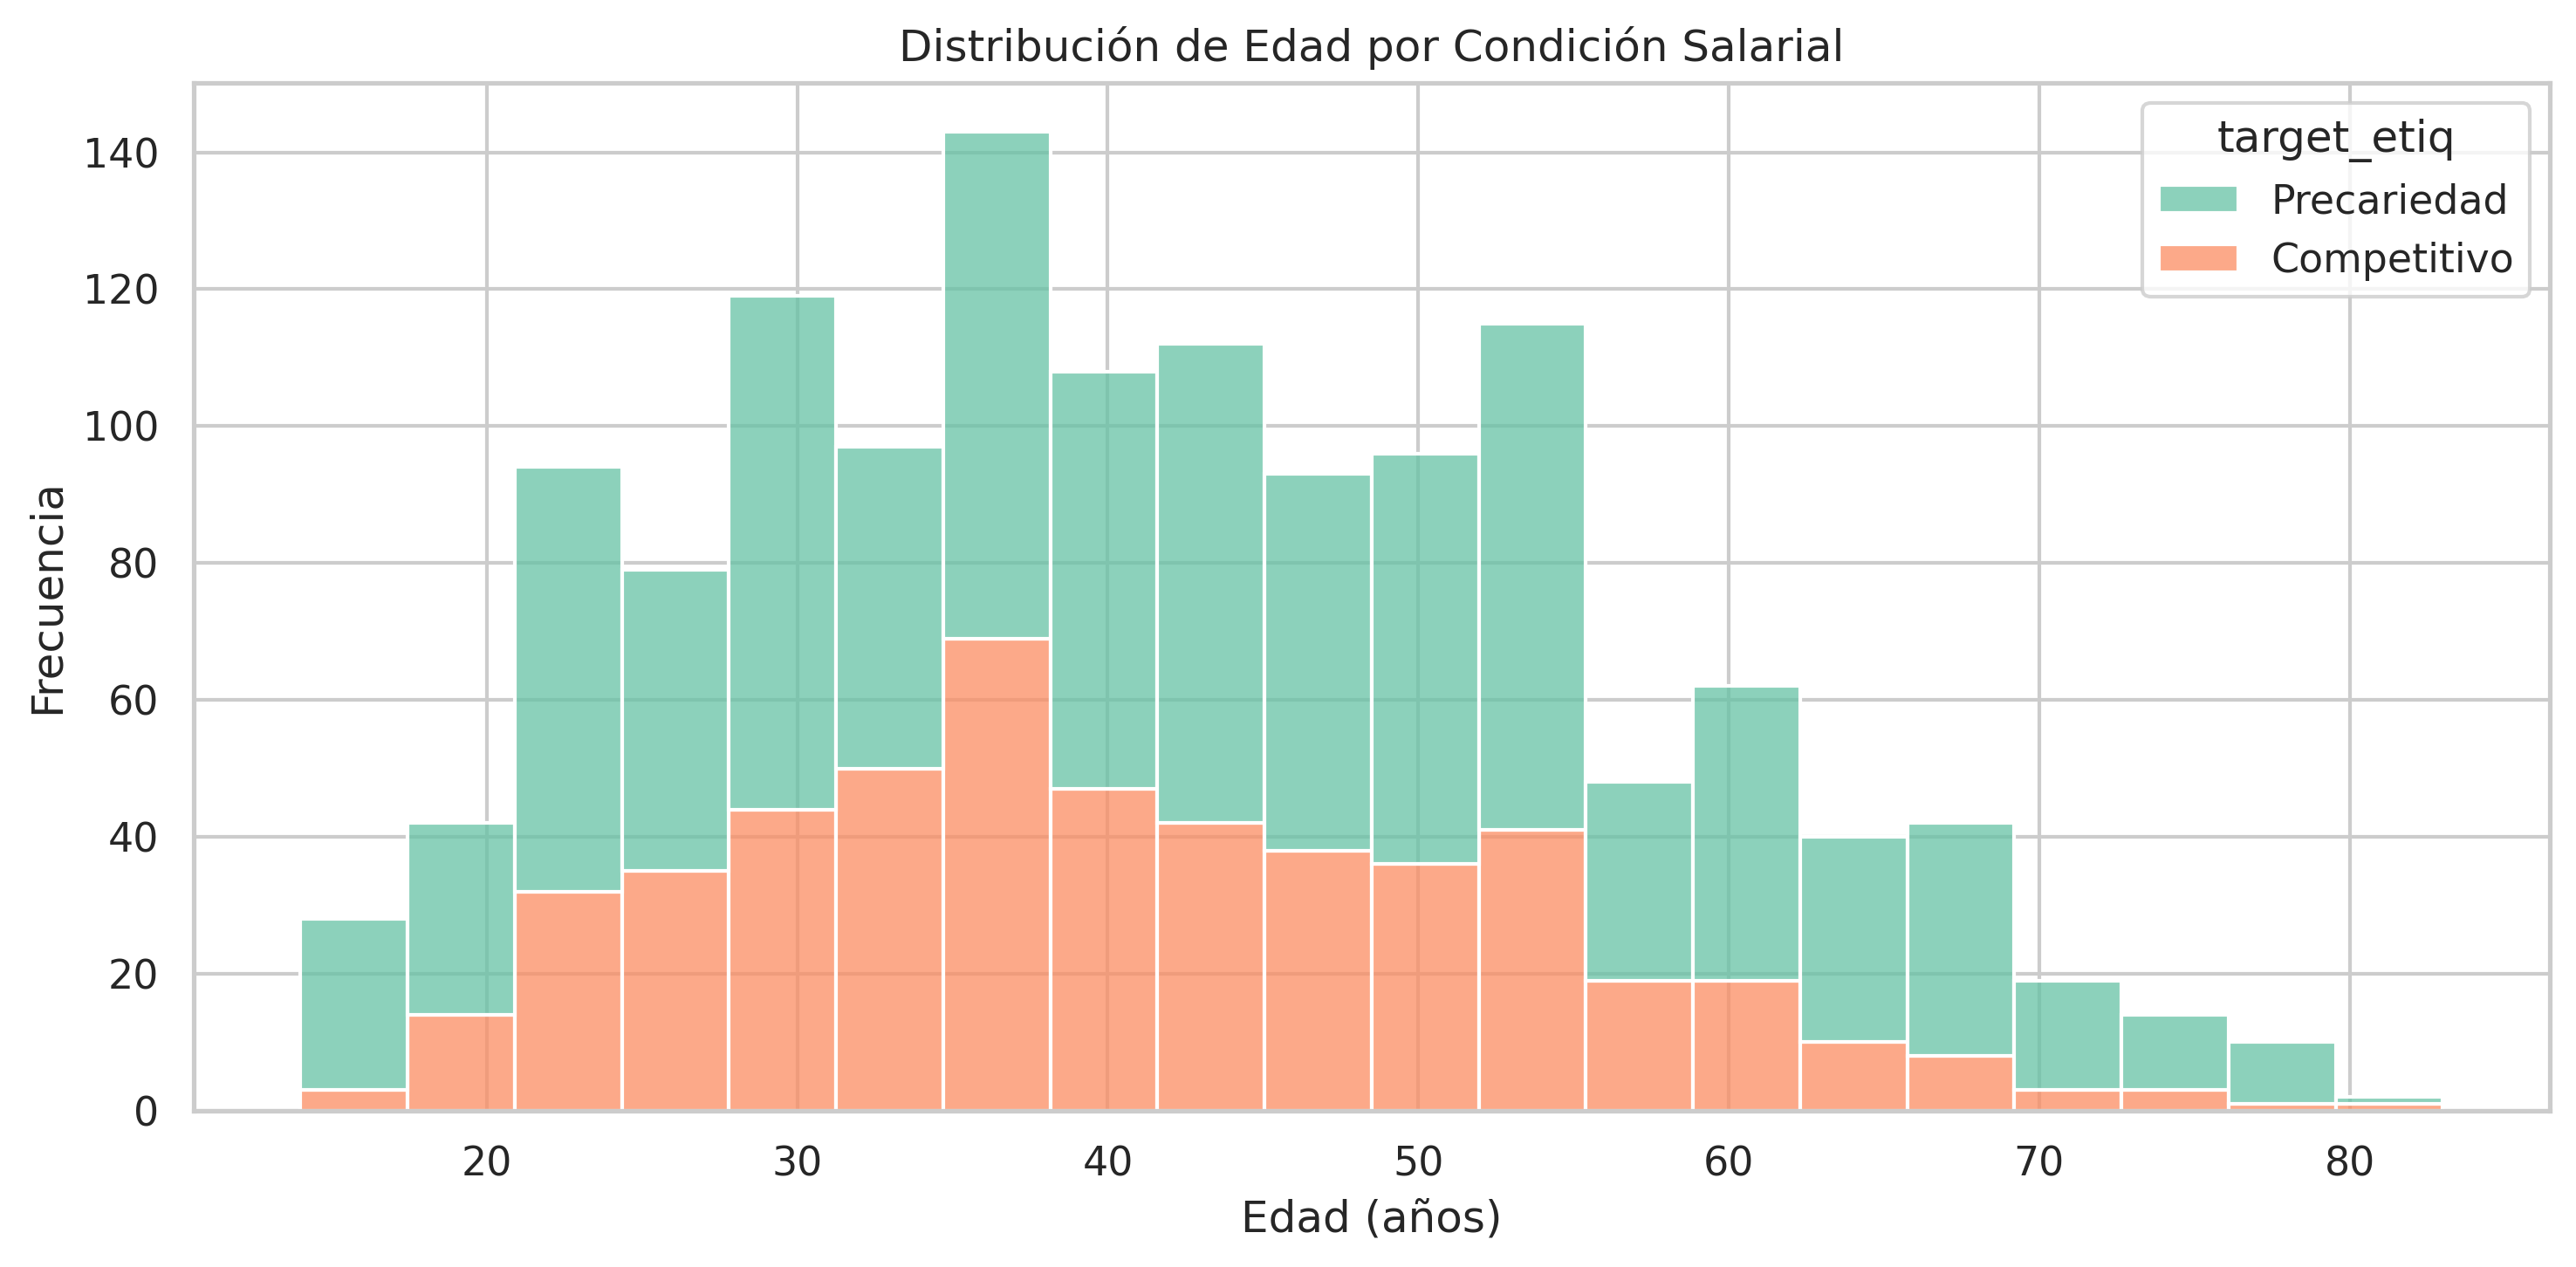

**Interpretación:** La distribución de la edad permite visualizar la estructura etaria de la muestra. La mediana de edad para el grupo en precariedad es 42.0 años, frente a 39.0 años en el grupo competitivo. Esta comparación descriptiva indica la concentración de la fuerza laboral y las sutiles diferencias entre ambas condiciones, lo que amerita consideración en el posterior modelado.

In [7]:
# Edad
plt.figure(figsize=(10, 5))
sns.histplot(data=df_plot, x='edad', hue='target_etiq', multiple='stack', bins=20, palette='Set2')
plt.title('Distribución de Edad por Condición Salarial')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('figuras_eda/fig_5_2_edad.png')
plt.show()

edad_prec = df_plot[df_plot['target_etiq'] == 'Precariedad']['edad'].median()
edad_comp = df_plot[df_plot['target_etiq'] == 'Competitivo']['edad'].median()

display(Markdown(f"**Interpretación:** La distribución de la edad permite visualizar la estructura etaria de la muestra. La mediana de edad para el grupo en precariedad es {edad_prec:.1f} años, frente a {edad_comp:.1f} años en el grupo competitivo. Esta comparación descriptiva indica la concentración de la fuerza laboral y las sutiles diferencias entre ambas condiciones, lo que amerita consideración en el posterior modelado."))

## 5.3 Características laborales y sectoriales

En esta sección se exploran las variables asociadas a la inserción laboral y su relación descriptiva con la precariedad salarial.

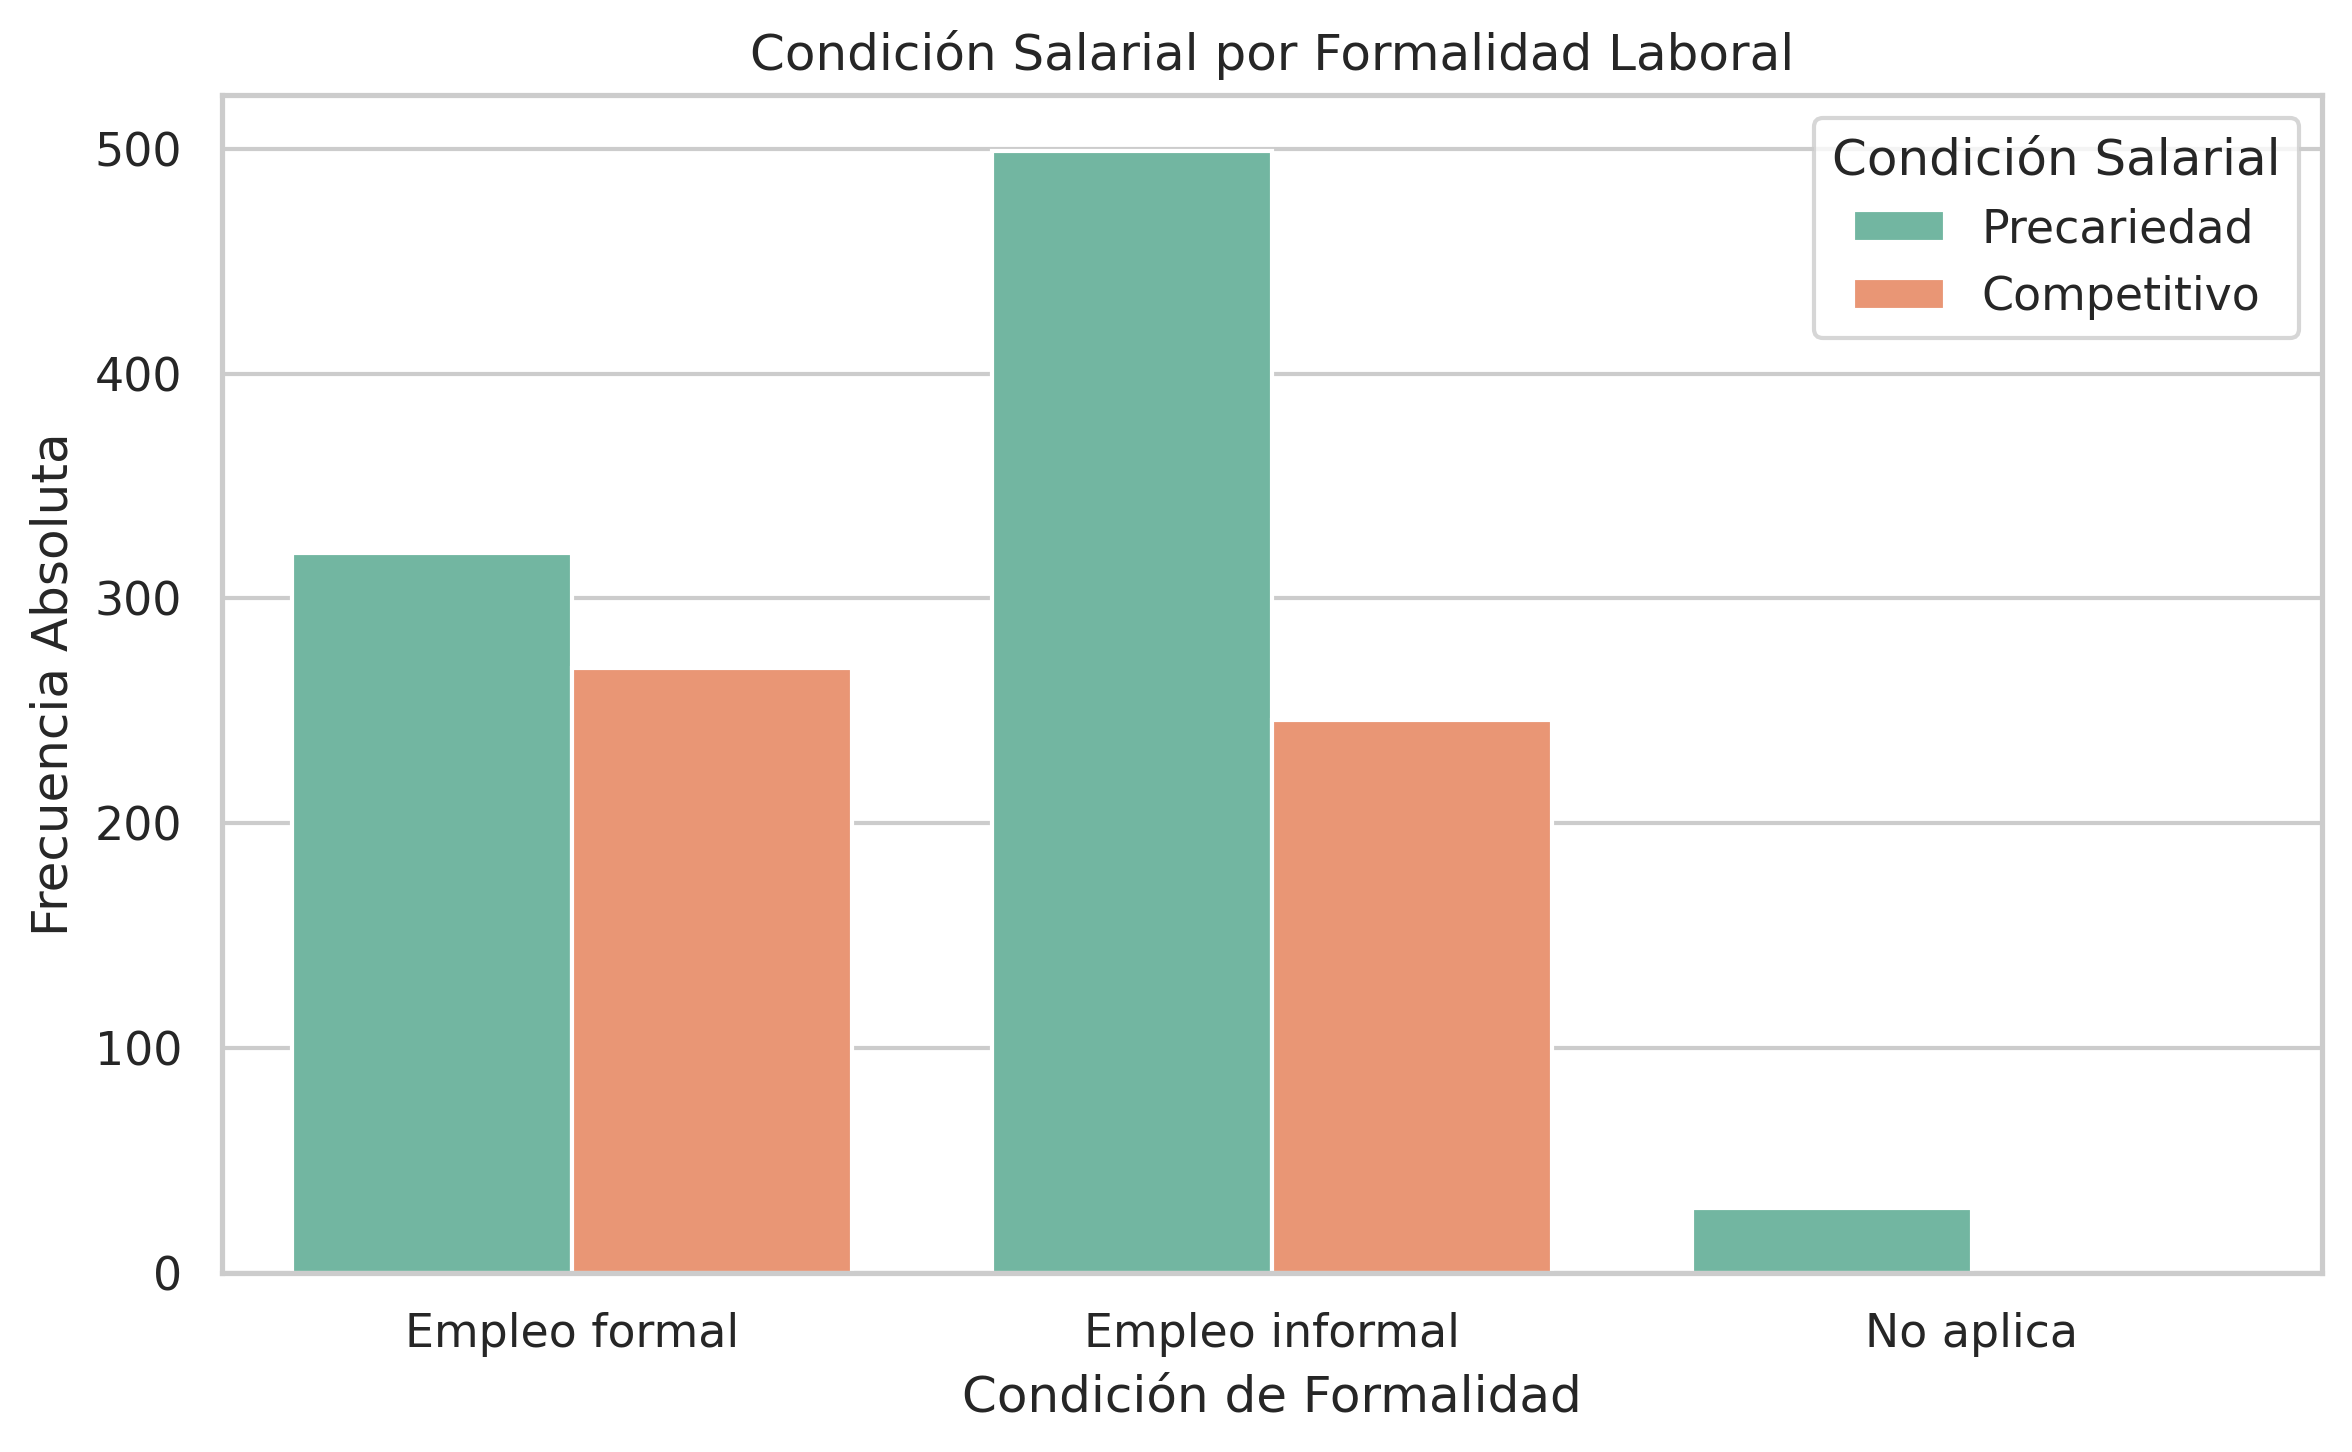

**Interpretación:** El análisis de la formalidad laboral evidencia que dentro de la categoría de Empleo informal, el 67.0% de las observaciones se clasifica en precariedad salarial. Este patrón sugiere que la falta de formalidad se asocia descriptivamente con ingresos por debajo del umbral establecido, un hallazgo relevante para comprender el fenómeno en la región analizada sin afirmar causalidad directa.

In [8]:
# Preparación de etiquetas 5.3
df_plot['formal_etiq'] = df_plot['emp_formal_inf'].map(map_emp_formal_inf)

# Gráfico Formalidad
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_plot, x='formal_etiq', hue='target_etiq', palette='Set2')
plt.title('Condición Salarial por Formalidad Laboral')
plt.xlabel('Condición de Formalidad')
plt.ylabel('Frecuencia Absoluta')
plt.legend(title='Condición Salarial')
plt.tight_layout()
plt.savefig('figuras_eda/fig_5_3_formalidad.png')
plt.show()

inf_prec = len(df_plot[(df_plot['formal_etiq'] == 'Empleo informal') & (df_plot['target_etiq'] == 'Precariedad')])
total_inf = len(df_plot[df_plot['formal_etiq'] == 'Empleo informal'])
prop_inf = (inf_prec/total_inf)*100 if total_inf > 0 else 0

display(Markdown(f"**Interpretación:** El análisis de la formalidad laboral evidencia que dentro de la categoría de Empleo informal, el {prop_inf:.1f}% de las observaciones se clasifica en precariedad salarial. Este patrón sugiere que la falta de formalidad se asocia descriptivamente con ingresos por debajo del umbral establecido, un hallazgo relevante para comprender el fenómeno en la región analizada sin afirmar causalidad directa."))

### Estado civil
Análisis descriptivo de la precariedad salarial según el estado civil.

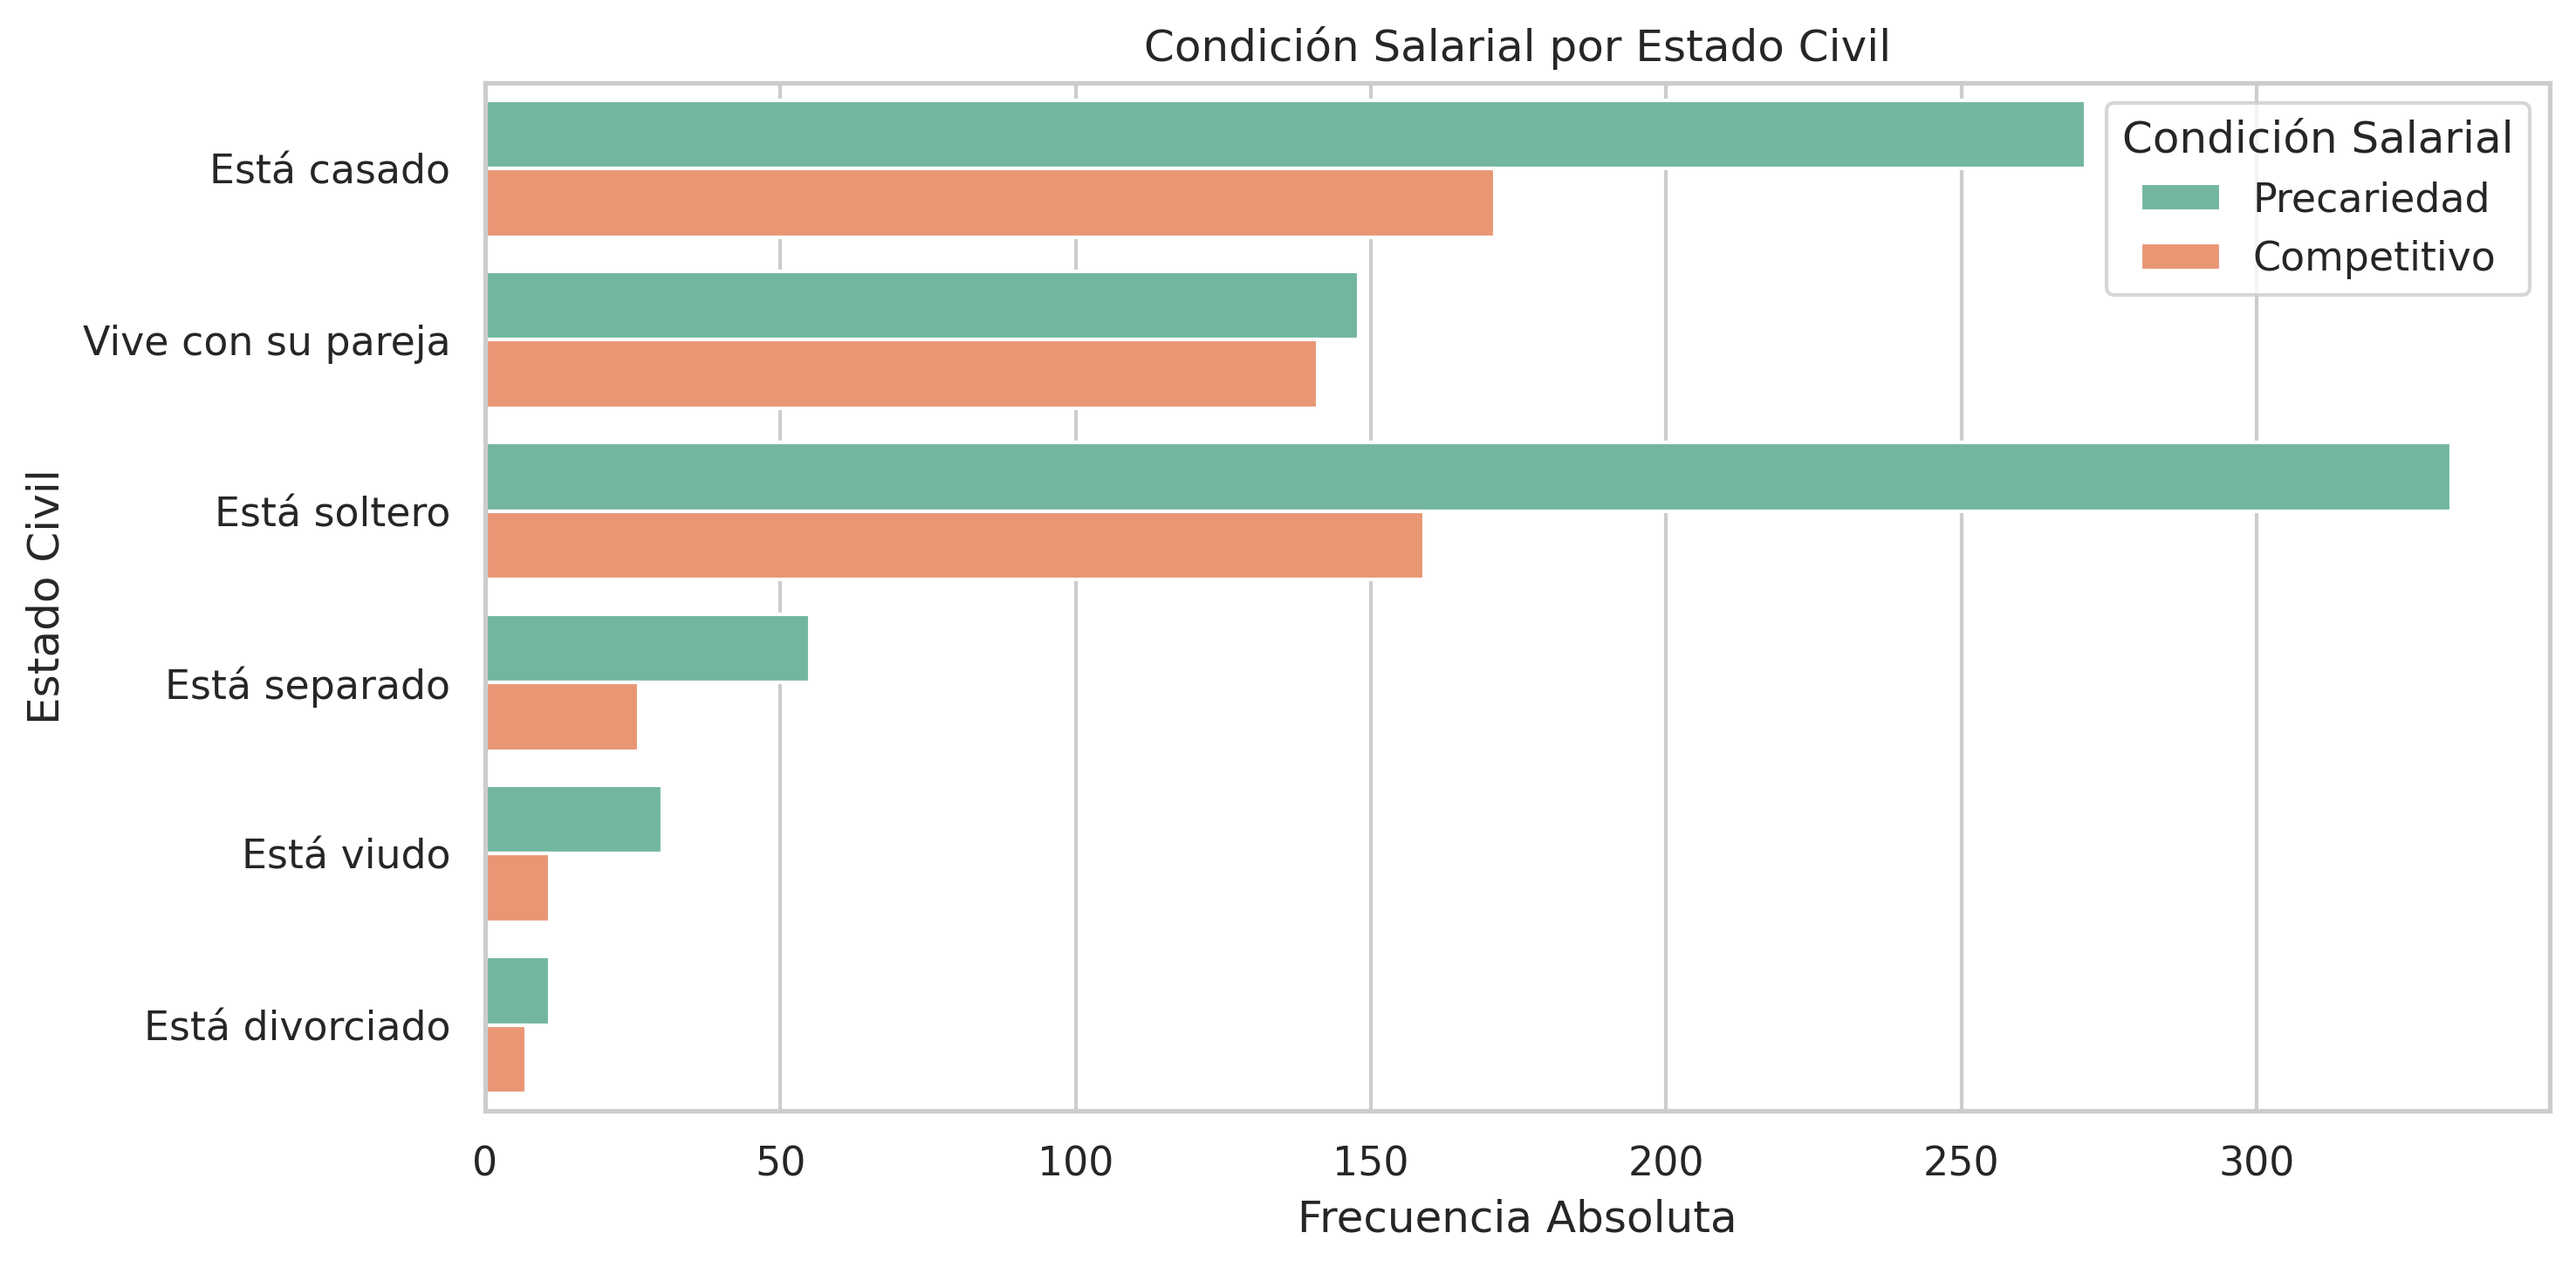

**Interpretación:** El gráfico de barras horizontales muestra la distribución del estado civil en función de la condición salarial. Permite identificar las categorías predominantes (por ejemplo, personas que viven con su pareja o están casadas) y observar si existe una mayor proporción de precariedad en ciertos grupos, lo cual constituye una asociación descriptiva preliminar.

In [9]:
df_plot['edo_civil_etiq'] = df_plot['edo_civil'].map(map_edo_civil)

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_plot, y='edo_civil_etiq', hue='target_etiq', palette='Set2')
plt.title('Condición Salarial por Estado Civil')
plt.xlabel('Frecuencia Absoluta')
plt.ylabel('Estado Civil')
plt.legend(title='Condición Salarial')
plt.tight_layout()
plt.savefig('figuras_eda/fig_5_2_edo_civil.png')
plt.show()

display(Markdown("**Interpretación:** El gráfico de barras horizontales muestra la distribución del estado civil en función de la condición salarial. Permite identificar las categorías predominantes (por ejemplo, personas que viven con su pareja o están casadas) y observar si existe una mayor proporción de precariedad en ciertos grupos, lo cual constituye una asociación descriptiva preliminar."))

### Estrato
Comparación descriptiva entre los diferentes estratos socioeconómicos.

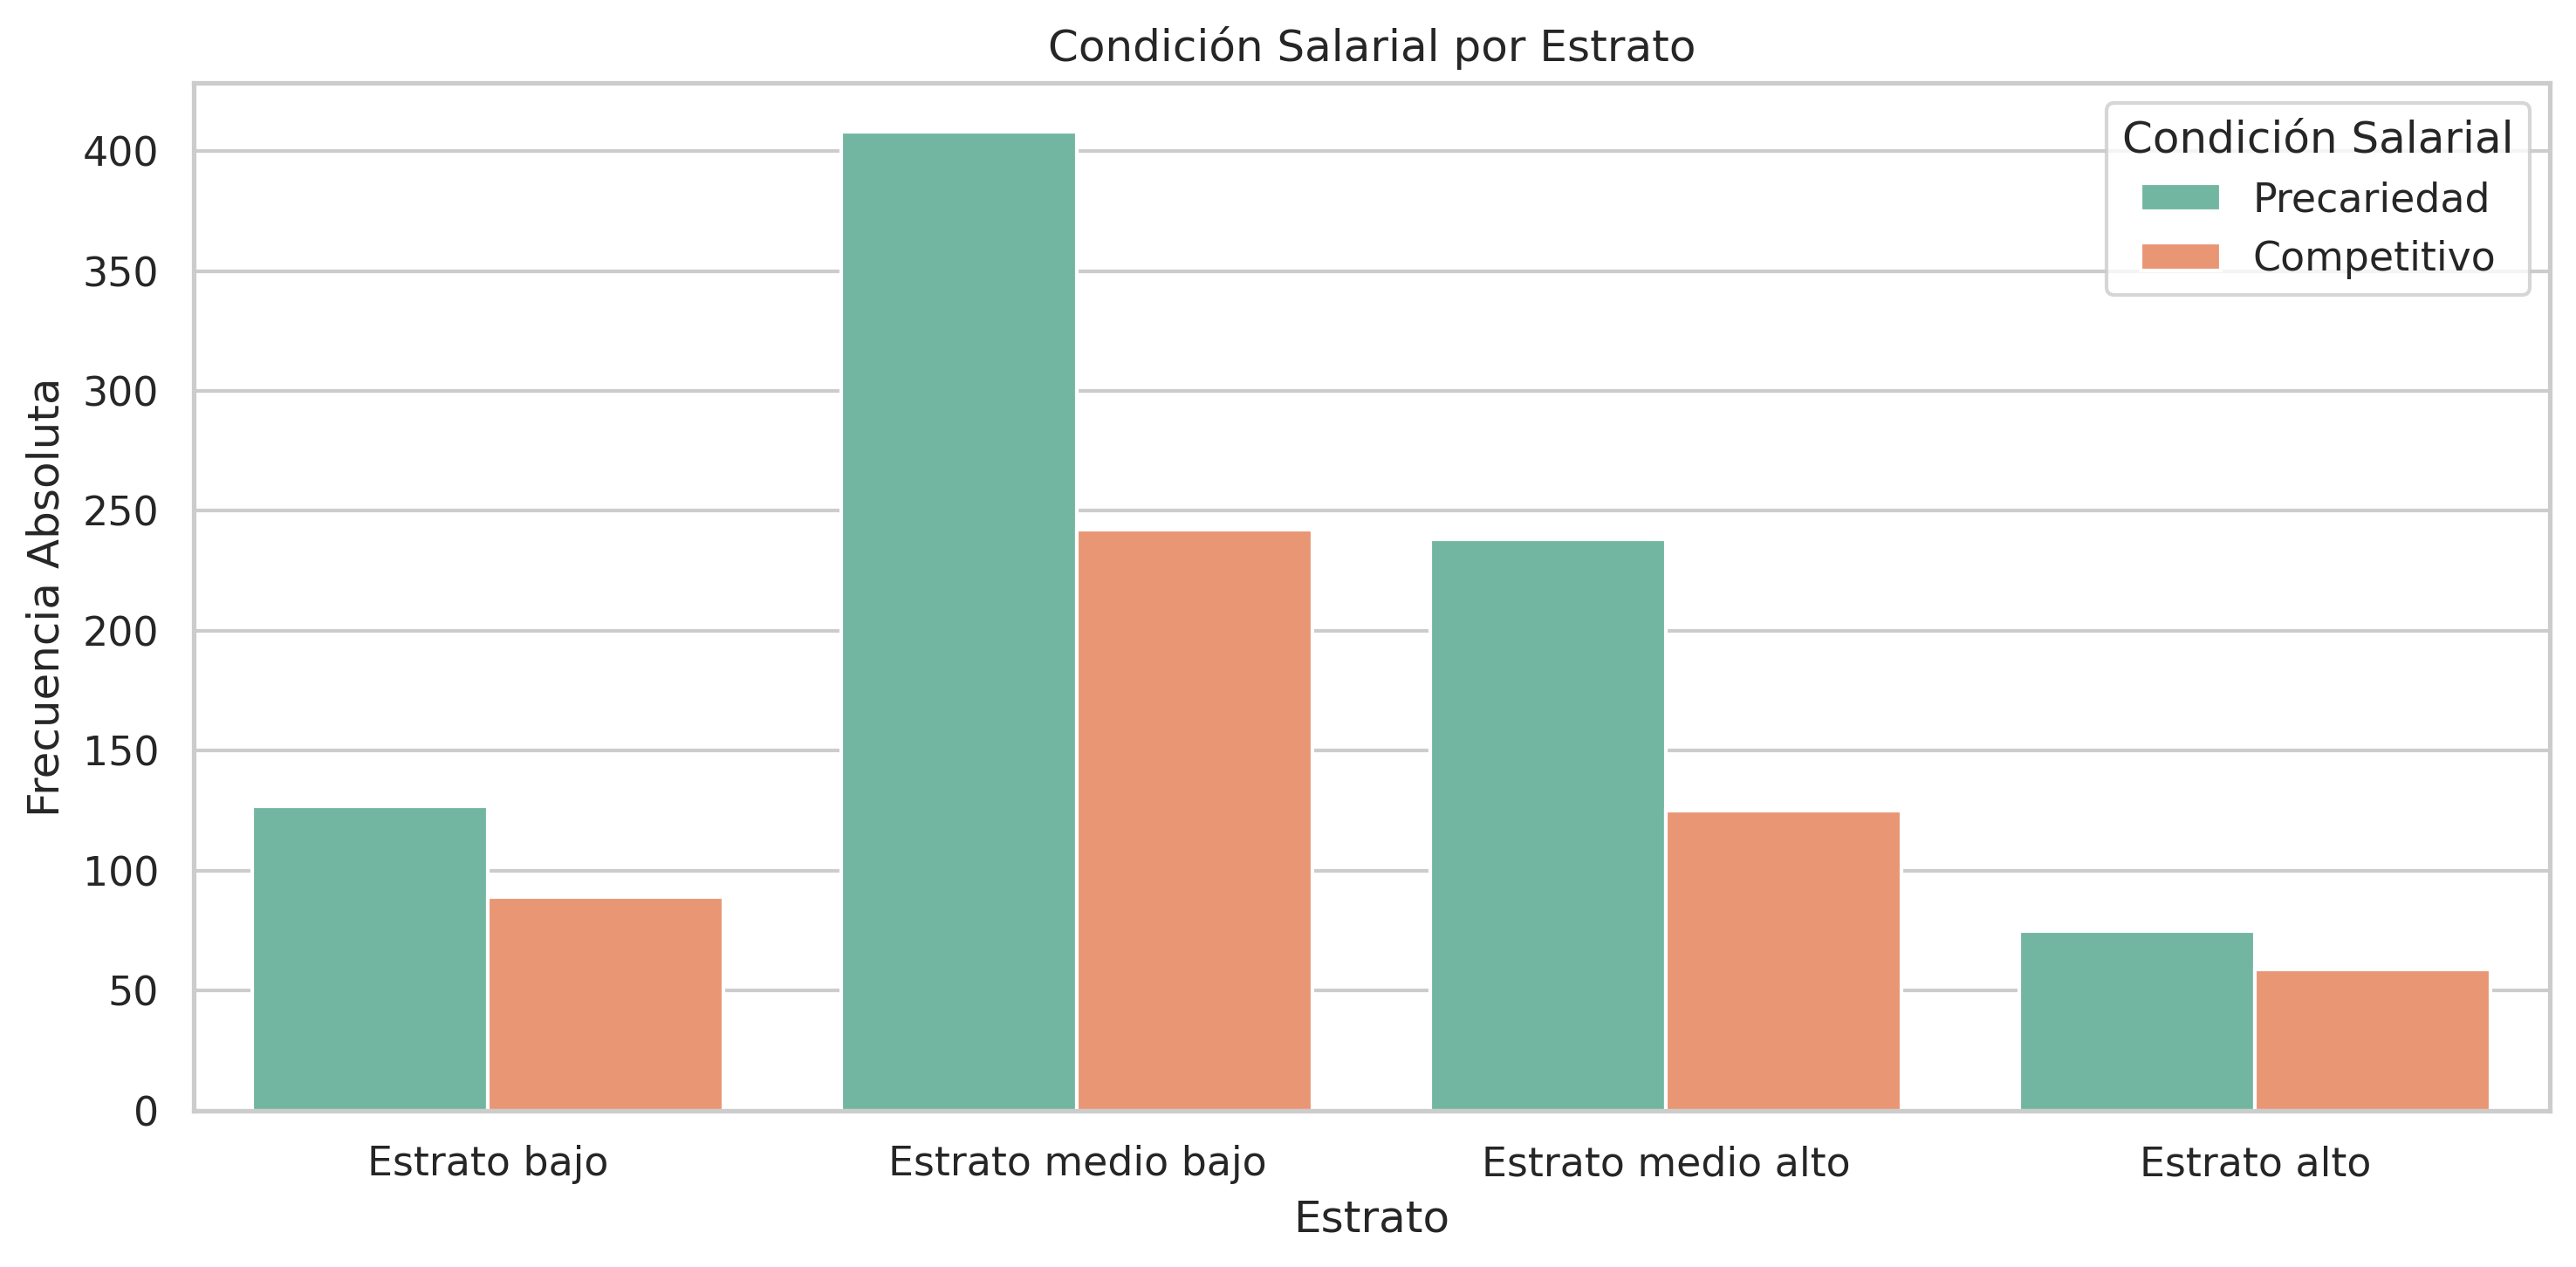

**Interpretación:** Al evaluar el estrato, se aprecia la composición de la muestra en cada nivel socioeconómico. Se observan diferencias descriptivas en la frecuencia de precariedad entre los distintos estratos, indicando un posible patrón estructural que debe examinarse detalladamente.

In [10]:
df_plot['estrato_etiq'] = df_plot['estrato'].map(map_estrato)

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_plot, x='estrato_etiq', hue='target_etiq', palette='Set2', order=['Estrato bajo', 'Estrato medio bajo', 'Estrato medio alto', 'Estrato alto'])
plt.title('Condición Salarial por Estrato')
plt.xlabel('Estrato')
plt.ylabel('Frecuencia Absoluta')
plt.legend(title='Condición Salarial')
plt.tight_layout()
plt.savefig('figuras_eda/fig_5_2_estrato.png')
plt.show()

display(Markdown("**Interpretación:** Al evaluar el estrato, se aprecia la composición de la muestra en cada nivel socioeconómico. Se observan diferencias descriptivas en la frecuencia de precariedad entre los distintos estratos, indicando un posible patrón estructural que debe examinarse detalladamente."))

### Años de estudio
Análisis de la educación formal y su relación con la precariedad salarial.

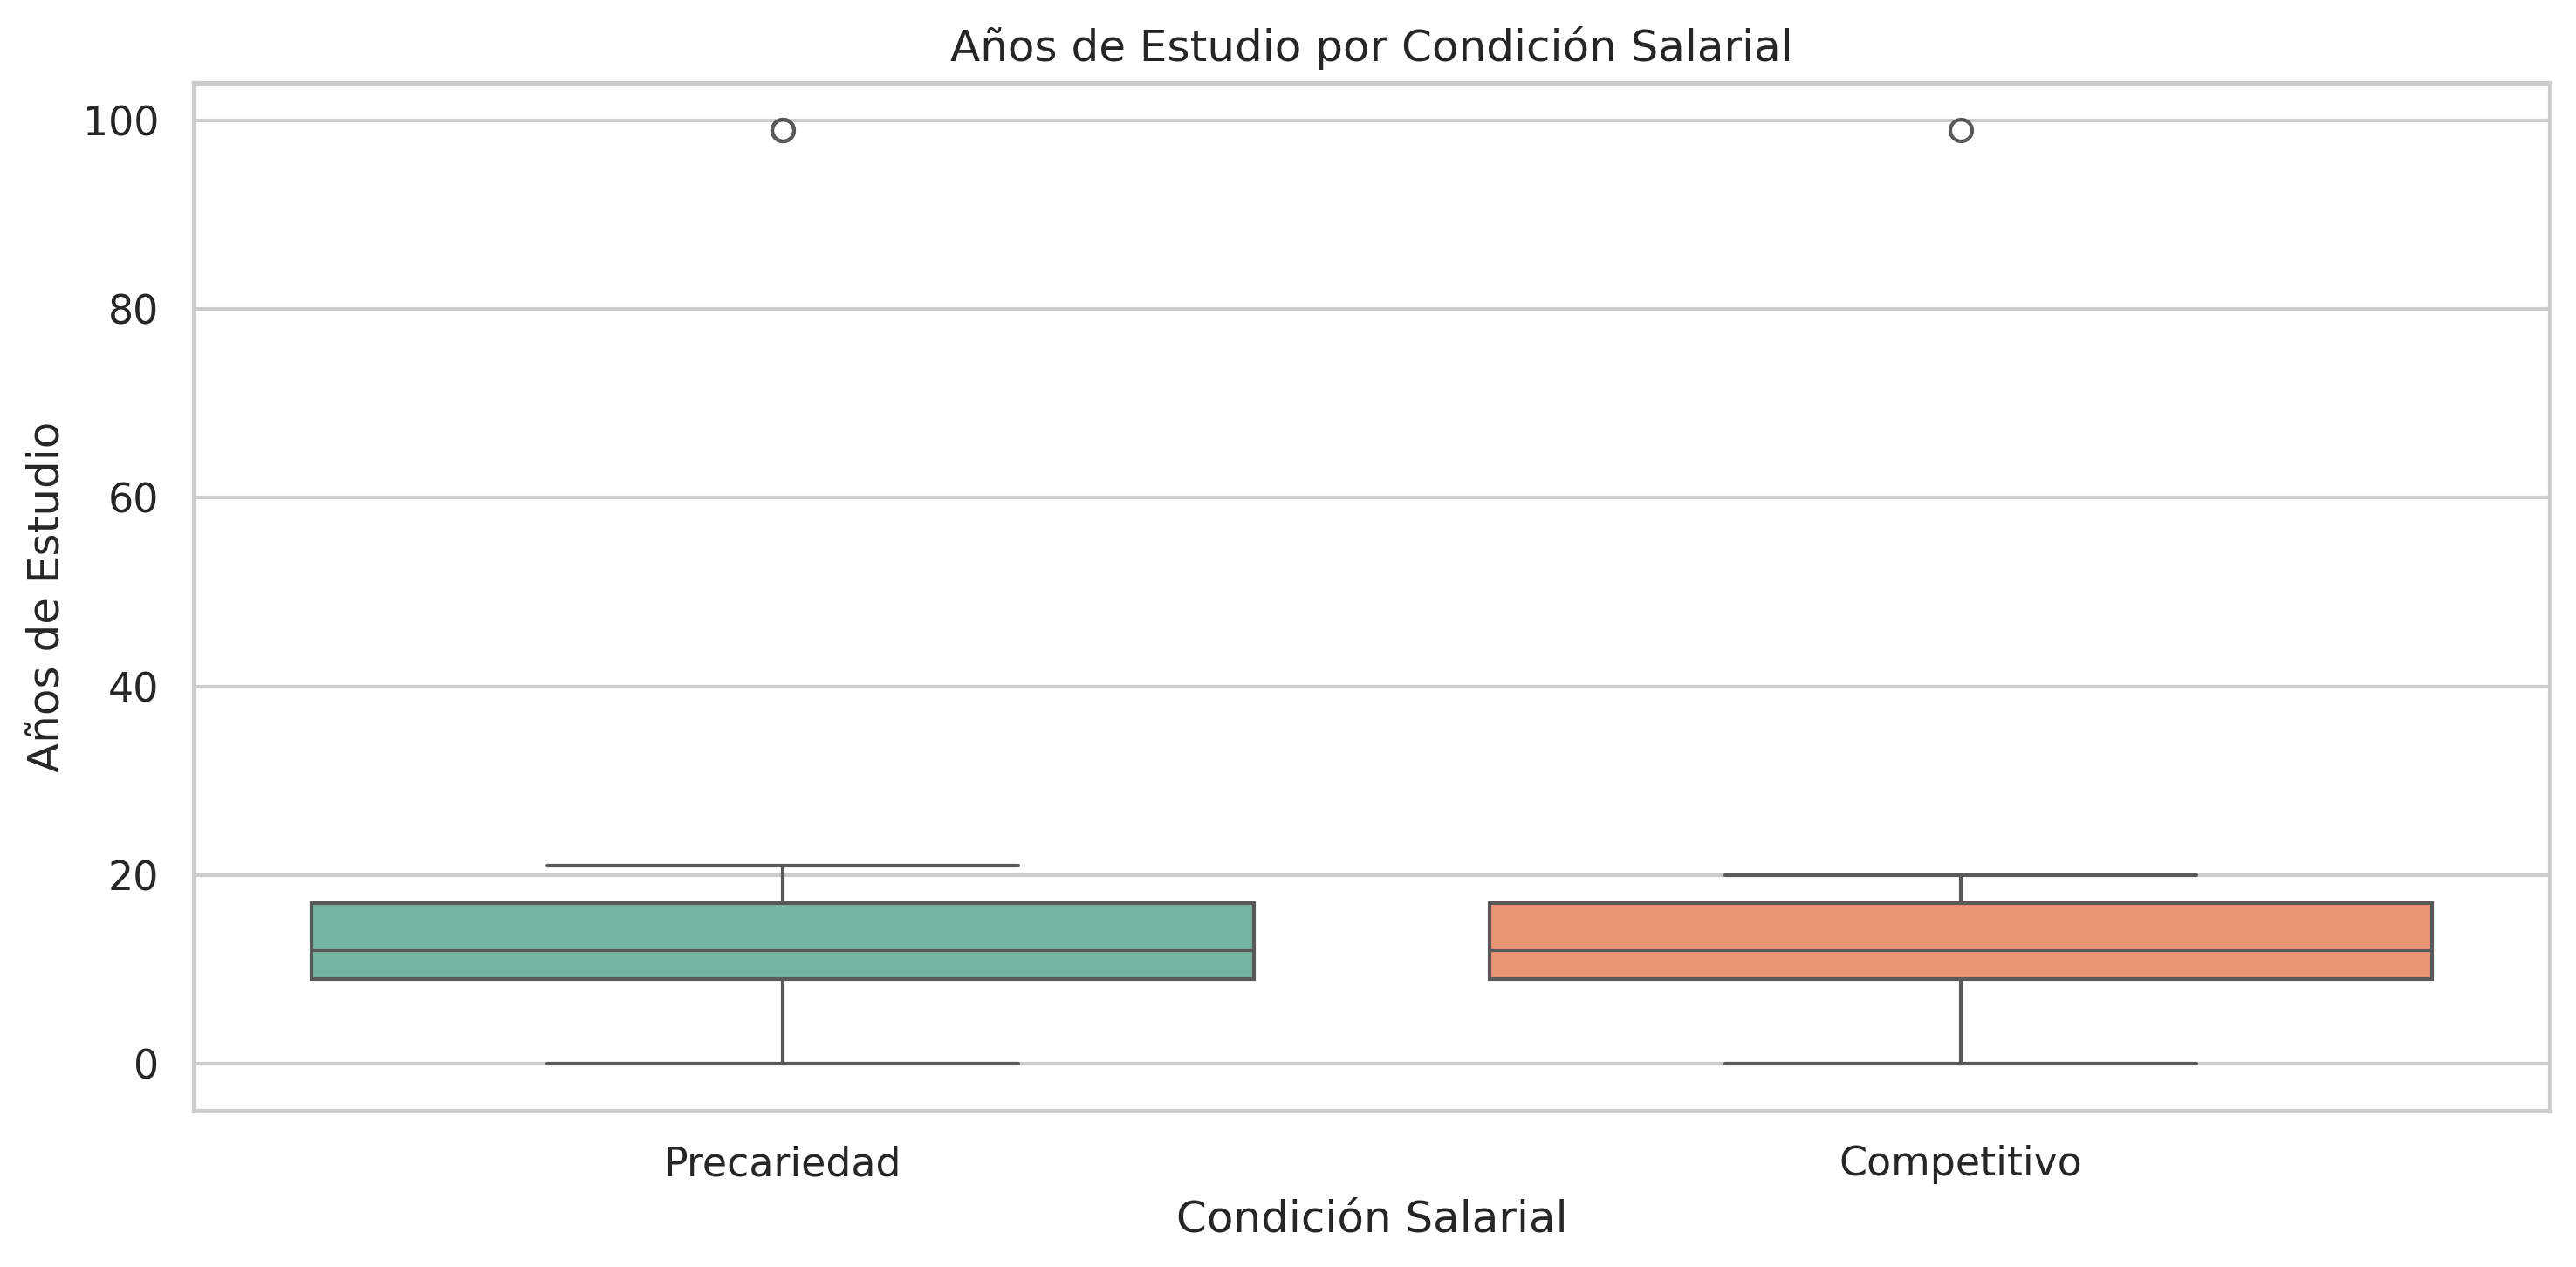

**Interpretación:** El boxplot ilustra la dispersión y la tendencia central de los años de estudio. La mediana para el grupo en precariedad es de 12.0 años, mientras que para el grupo competitivo es de 12.0 años. Esta diferencia sugiere que mayores niveles de escolaridad tienden a asociarse descriptivamente con una menor incidencia de precariedad.

In [12]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_plot, x='target_etiq', y='anios_estudio', hue='target_etiq', palette='Set2', legend=False)
plt.title('Años de Estudio por Condición Salarial')
plt.xlabel('Condición Salarial')
plt.ylabel('Años de Estudio')
plt.tight_layout()
plt.savefig('figuras_eda/fig_5_2_anios_estudio.png')
plt.show()

mediana_estudio_prec = df_plot[df_plot['target_etiq'] == 'Precariedad']['anios_estudio'].median()
mediana_estudio_comp = df_plot[df_plot['target_etiq'] == 'Competitivo']['anios_estudio'].median()

display(Markdown(f"**Interpretación:** El boxplot ilustra la dispersión y la tendencia central de los años de estudio. La mediana para el grupo en precariedad es de {mediana_estudio_prec} años, mientras que para el grupo competitivo es de {mediana_estudio_comp} años. Esta diferencia sugiere que mayores niveles de escolaridad tienden a asociarse descriptivamente con una menor incidencia de precariedad."))

### Hallazgos principales del perfil sociodemográfico

El análisis bivariado de las variables sociodemográficas revela asociaciones descriptivas de interés para la investigación. Se identifica una mayor incidencia porcentual de precariedad salarial entre las mujeres en comparación con los hombres. Respecto a la edad, ambos grupos presentan estructuras similares, aunque con ligeras variaciones en sus medidas de tendencia central. La escolaridad (años de estudio) muestra un patrón en el que un mayor nivel educativo coincide con una mayor presencia en la categoría de salarios competitivos. Estos hallazgos no implican causalidad, pero justifican metodológicamente la inclusión de estas variables en etapas posteriores de modelado.

### Población económicamente activa
Análisis de la precariedad salarial según la condición de actividad económica.

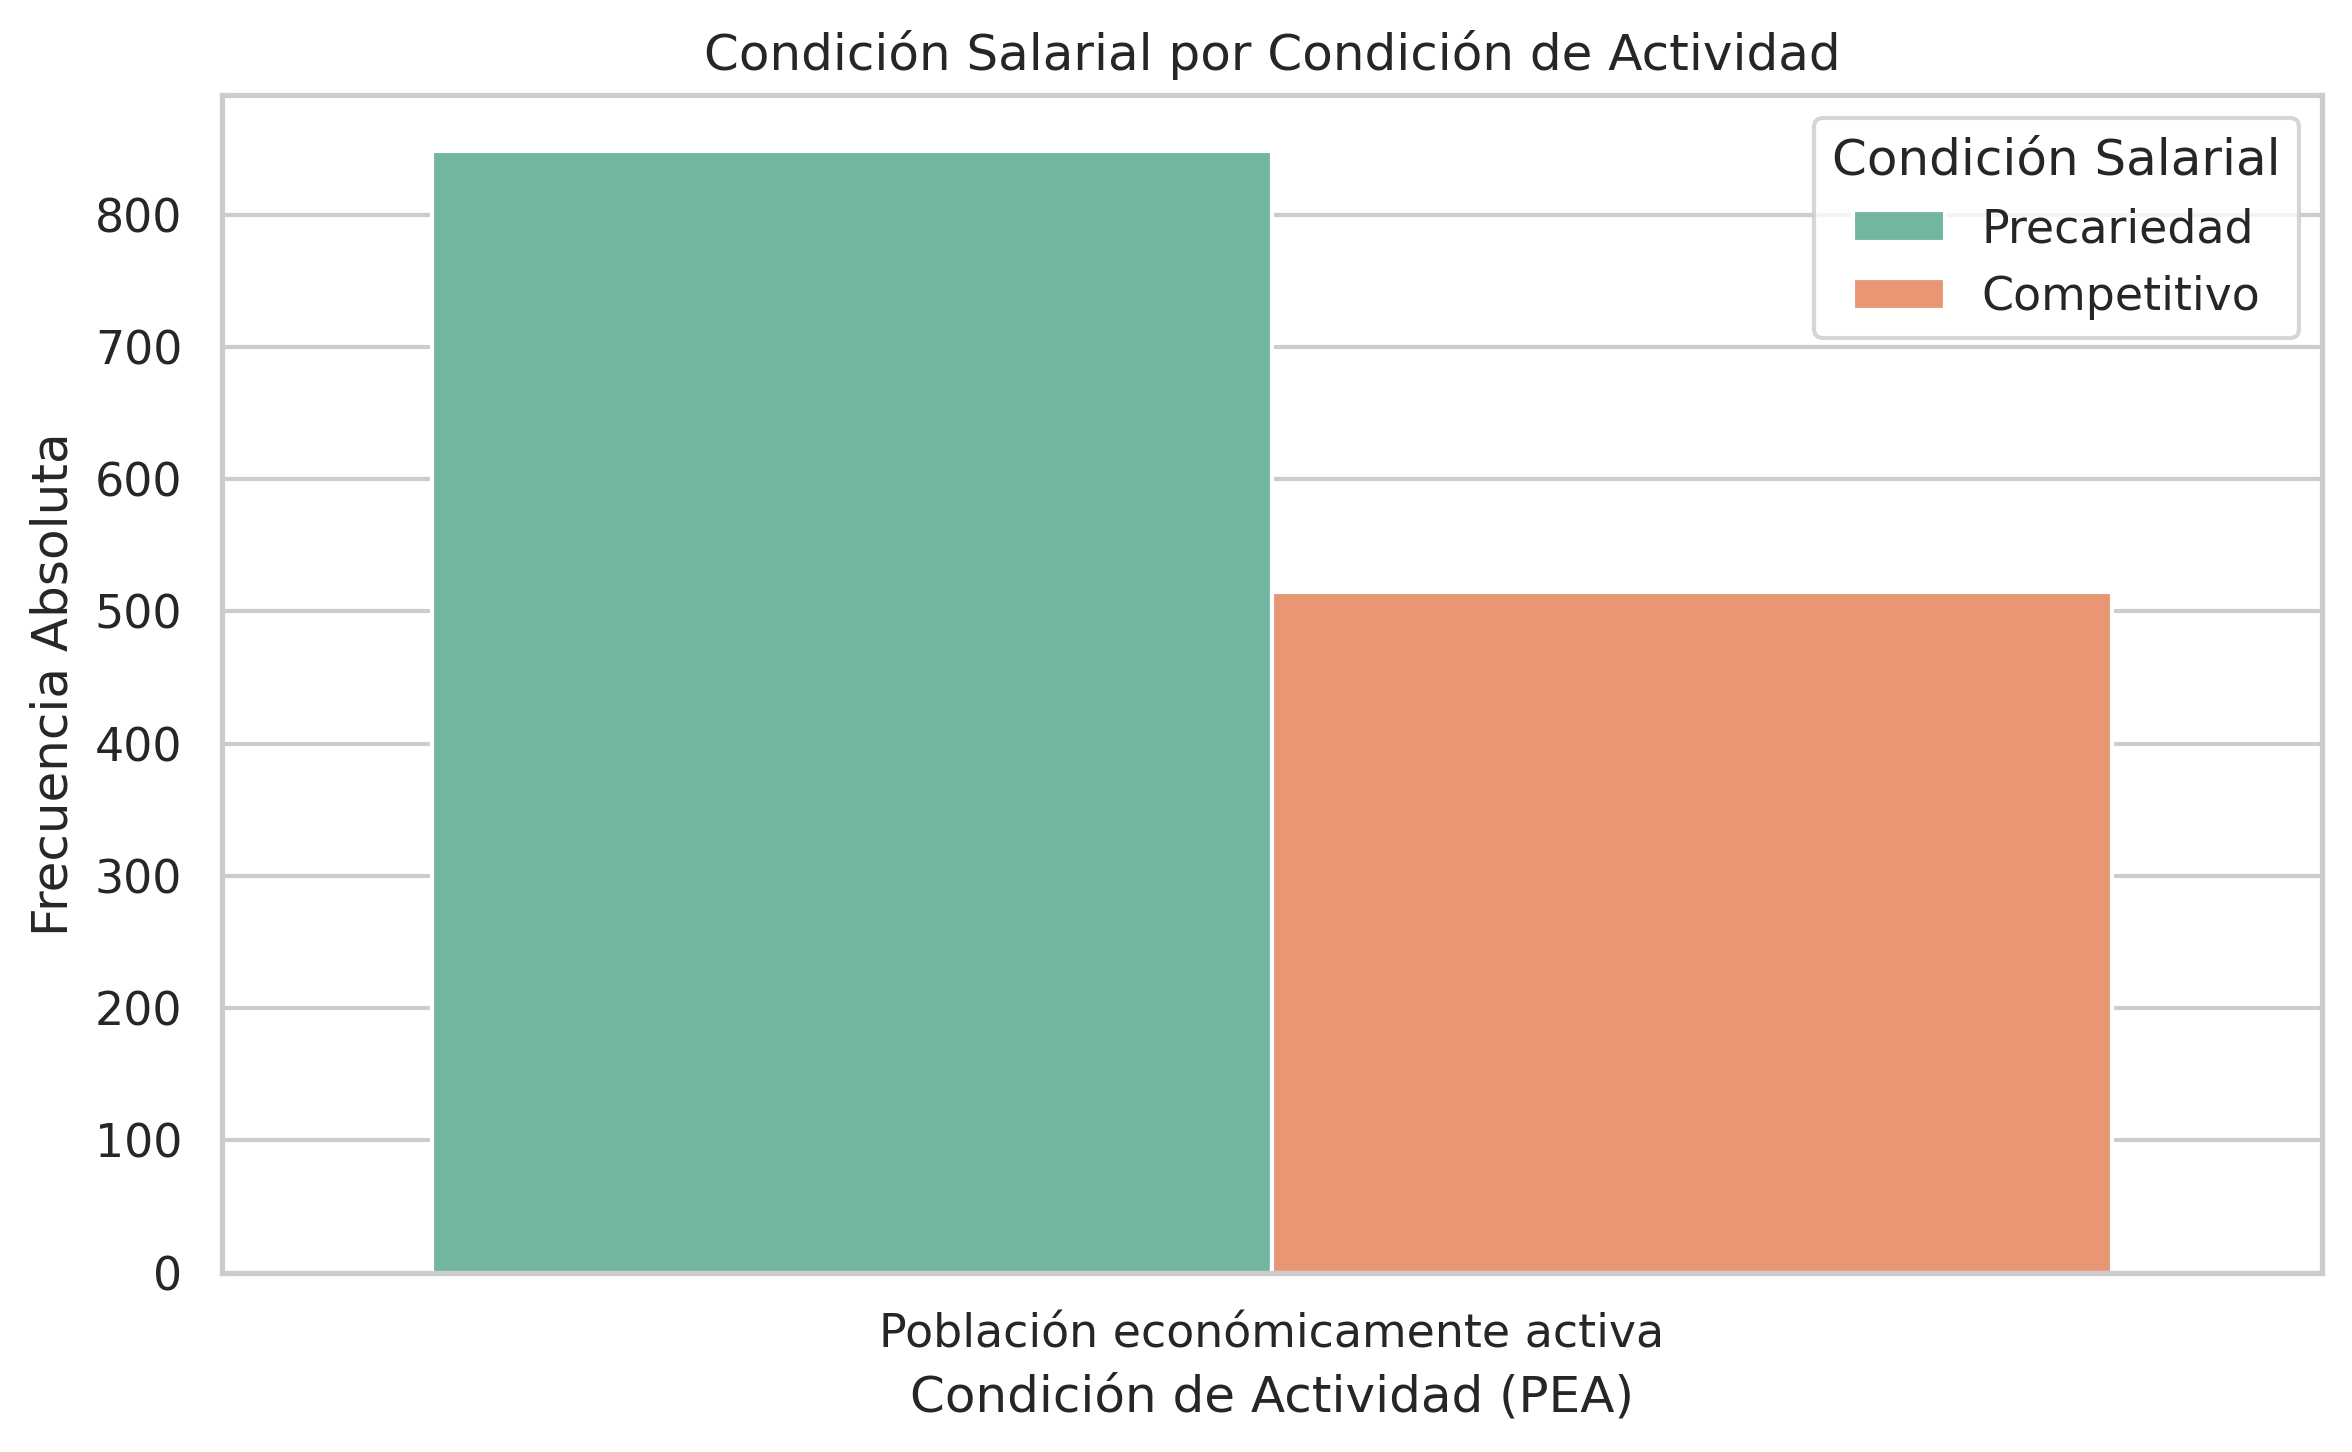

**Interpretación:** El gráfico detalla la composición de la Población Económicamente Activa frente a la no activa dentro de la muestra, contrastando su situación salarial. Permite visualizar que la mayor parte de las observaciones evaluadas corresponden efectivamente a población que reporta estar activa.

In [13]:
df_plot['pea_etiq'] = df_plot['pea_si_no'].map(map_pea)

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_plot, x='pea_etiq', hue='target_etiq', palette='Set2')
plt.title('Condición Salarial por Condición de Actividad')
plt.xlabel('Condición de Actividad (PEA)')
plt.ylabel('Frecuencia Absoluta')
plt.legend(title='Condición Salarial')
plt.tight_layout()
plt.savefig('figuras_eda/fig_5_3_pea.png')
plt.show()

display(Markdown("**Interpretación:** El gráfico detalla la composición de la Población Económicamente Activa frente a la no activa dentro de la muestra, contrastando su situación salarial. Permite visualizar que la mayor parte de las observaciones evaluadas corresponden efectivamente a población que reporta estar activa."))

### Tipo de empleado
Distribución de la precariedad según la posición en el trabajo.

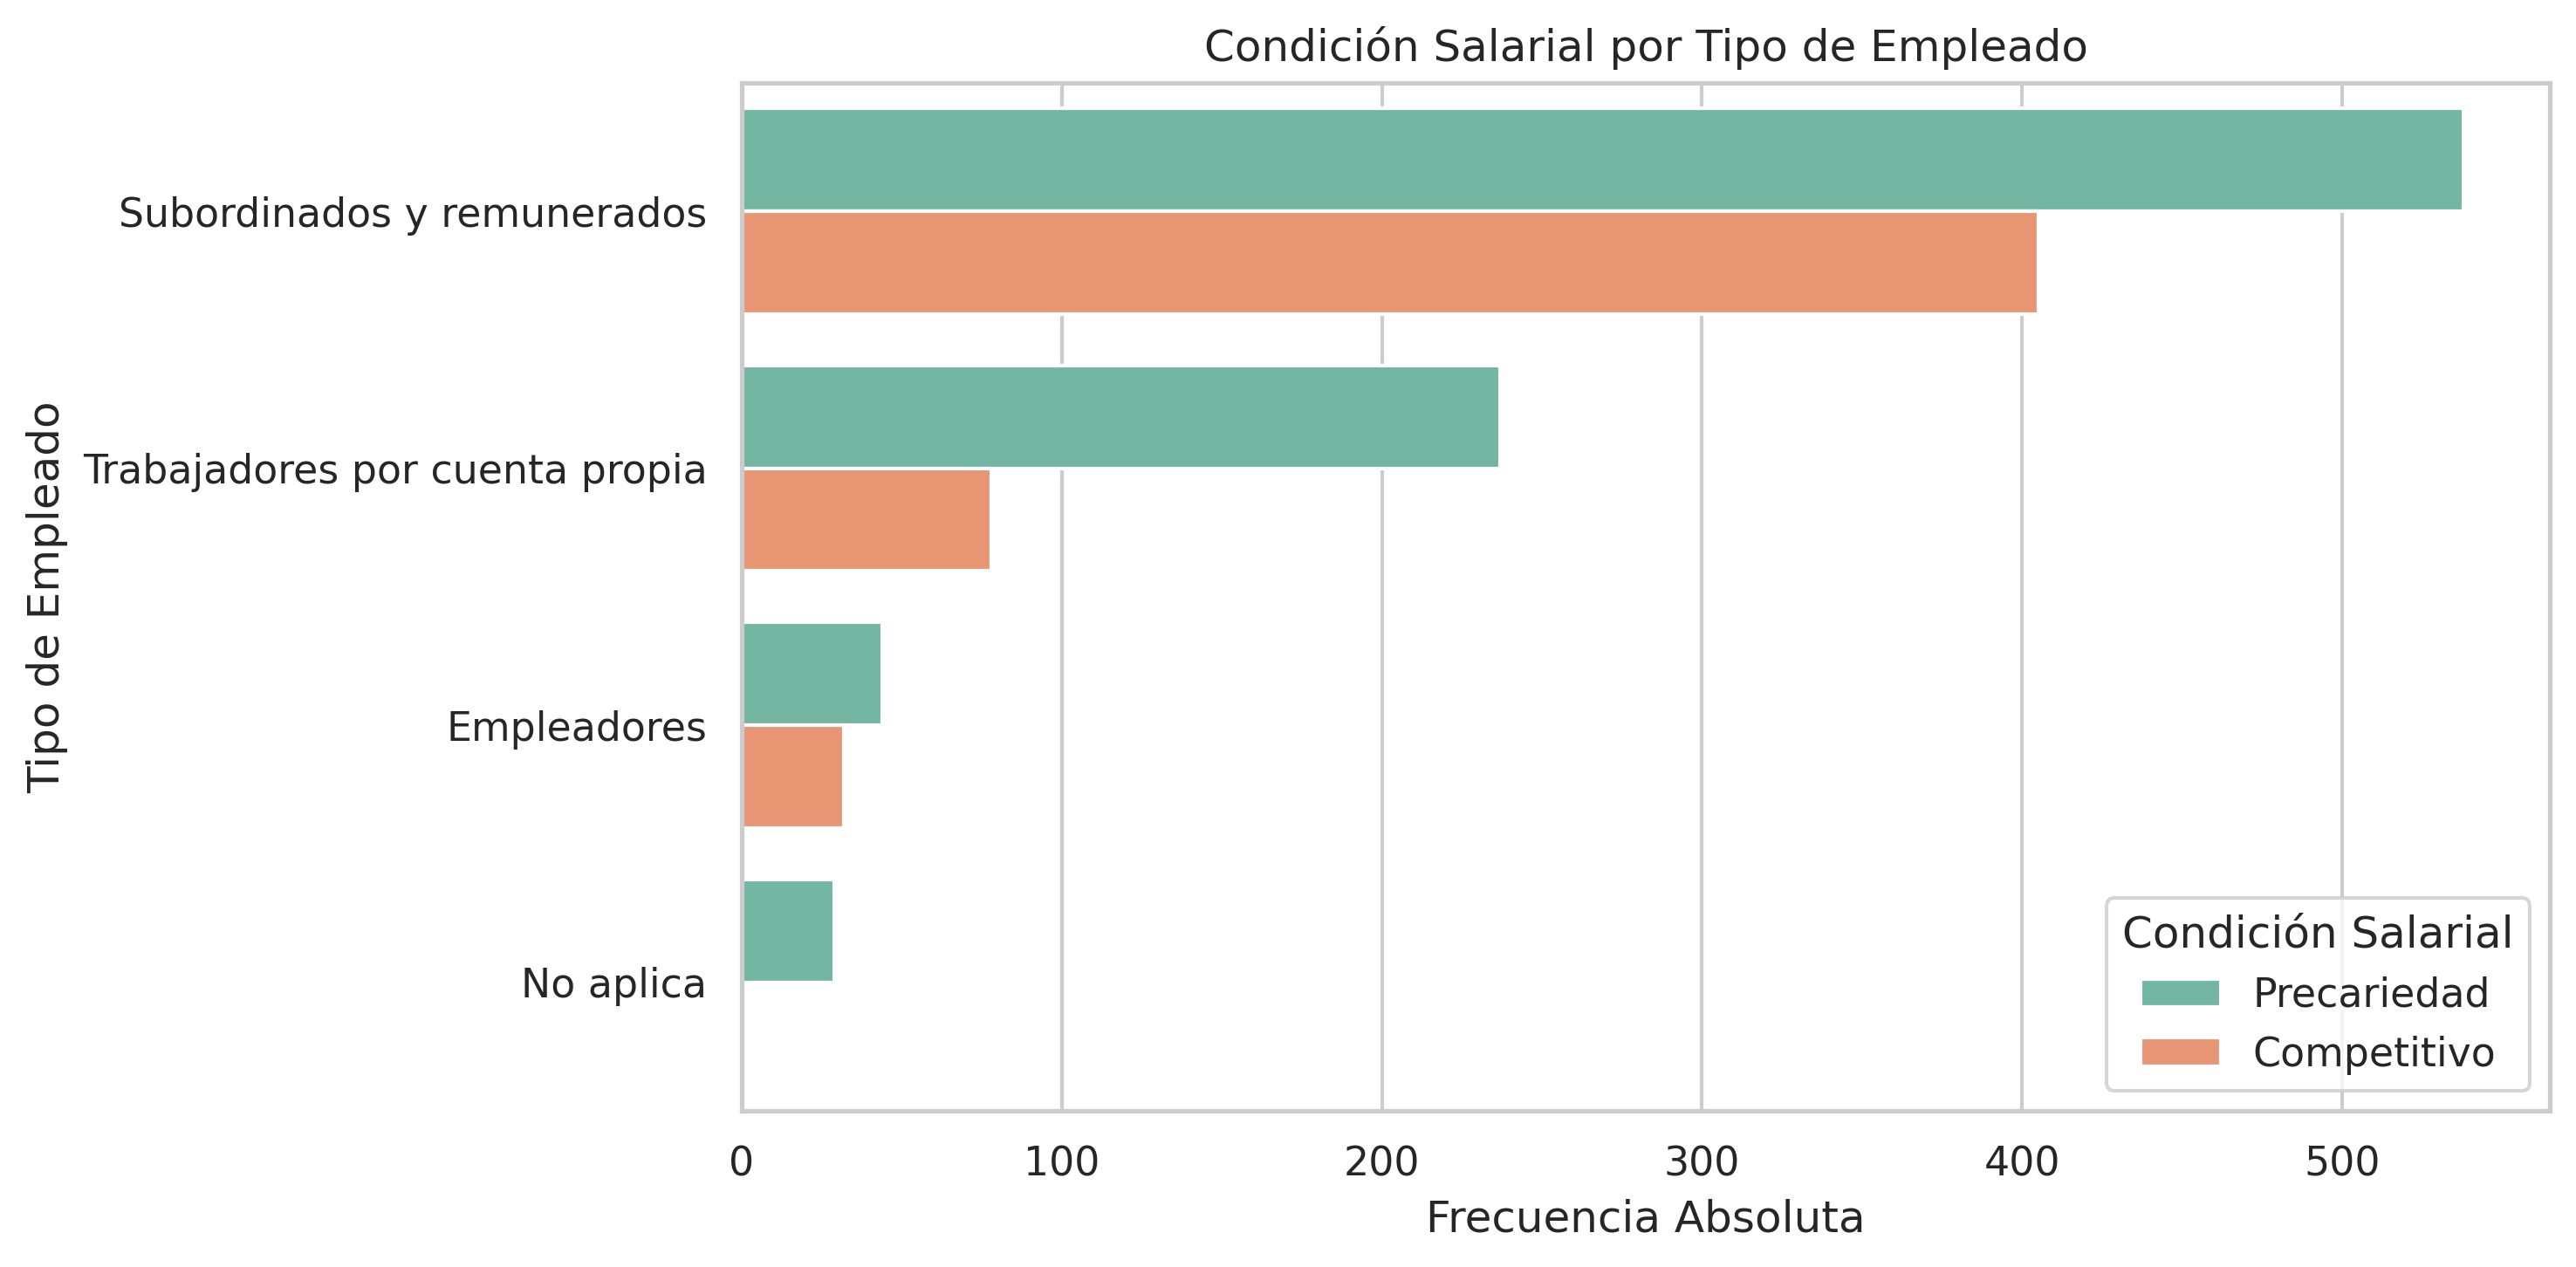

**Interpretación:** Al examinar el tipo de empleado, se identifican las diferencias entre subordinados, empleadores y trabajadores por cuenta propia. Las proporciones relativas de precariedad sugieren asociaciones descriptivas sobre cómo la modalidad de inserción laboral podría vincularse con los niveles de ingreso.

In [14]:
df_plot['empleado_etiq'] = df_plot['tipo_empleado'].map(map_tipo_empleado)

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_plot, y='empleado_etiq', hue='target_etiq', palette='Set2')
plt.title('Condición Salarial por Tipo de Empleado')
plt.xlabel('Frecuencia Absoluta')
plt.ylabel('Tipo de Empleado')
plt.legend(title='Condición Salarial')
plt.tight_layout()
plt.savefig('figuras_eda/fig_5_3_tipo_empleado.png')
plt.show()

display(Markdown("**Interpretación:** Al examinar el tipo de empleado, se identifican las diferencias entre subordinados, empleadores y trabajadores por cuenta propia. Las proporciones relativas de precariedad sugieren asociaciones descriptivas sobre cómo la modalidad de inserción laboral podría vincularse con los niveles de ingreso."))

### Tipo de empresa
Incidencia de precariedad salarial de acuerdo con el tamaño o tipo de unidad económica.

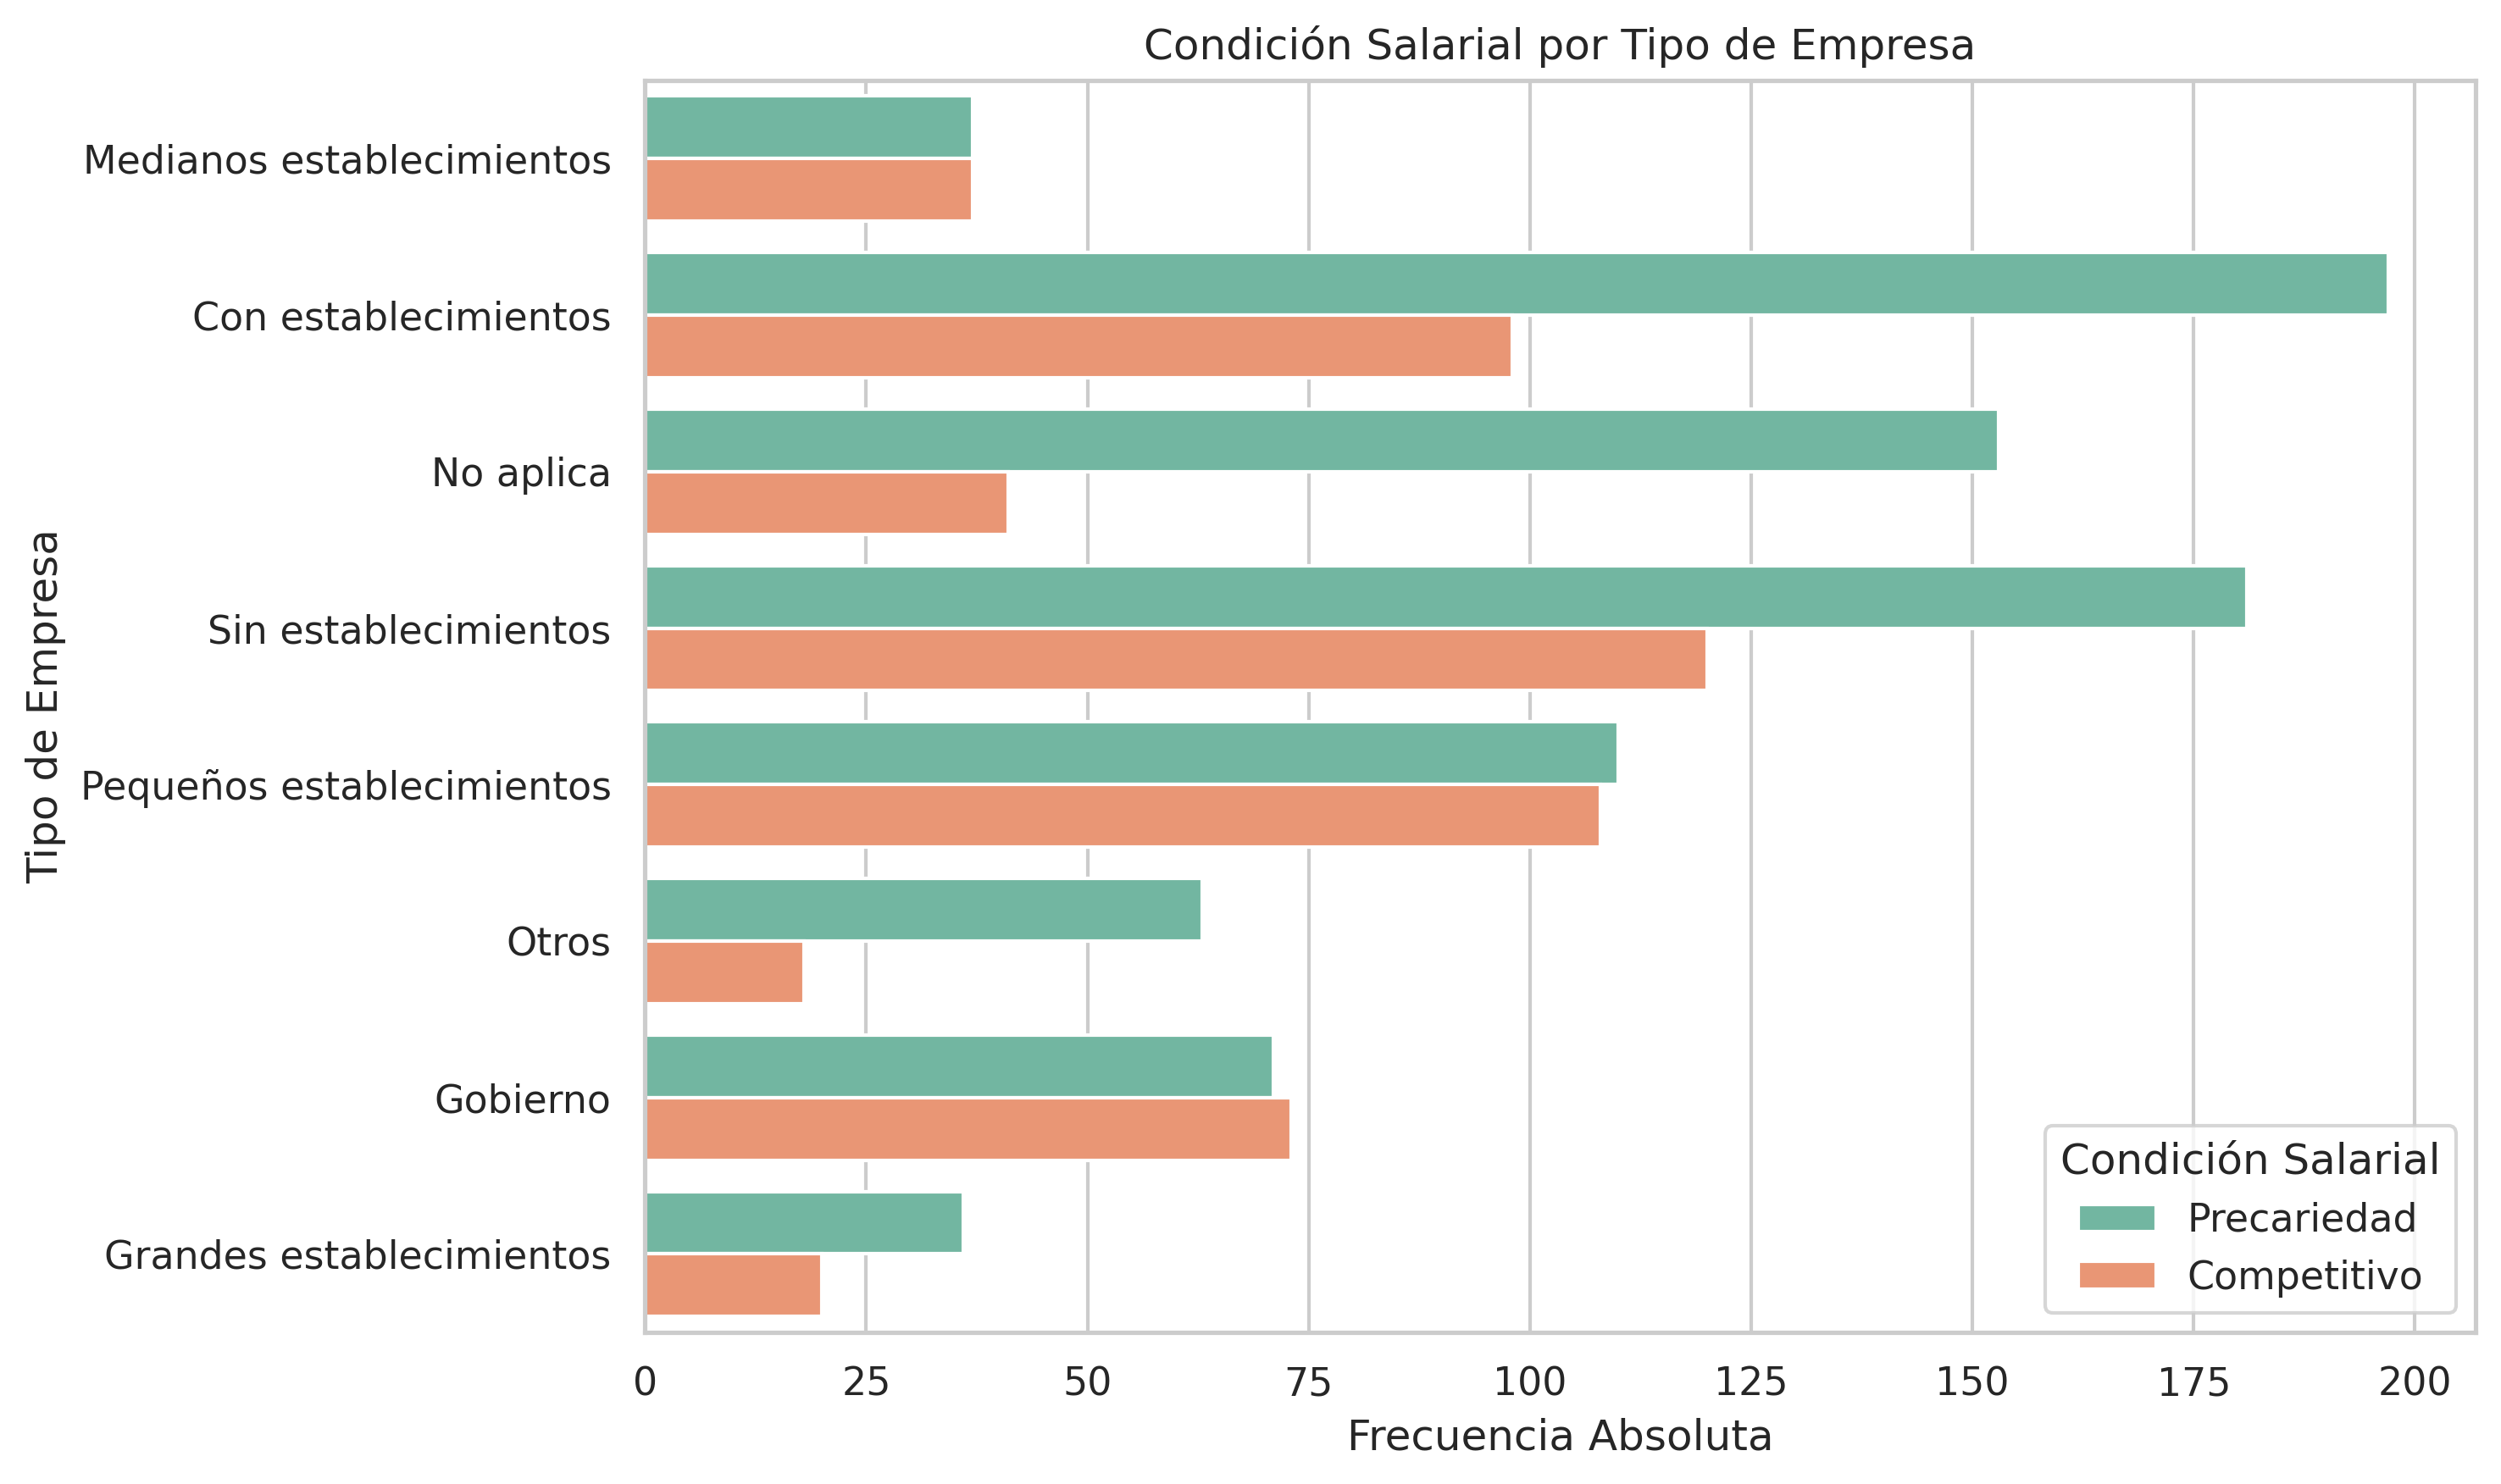

**Interpretación:** La distribución por tipo de empresa revela concentraciones importantes, como la prevalencia de micronegocios. Analizar estas categorías ayuda a comprender descriptivamente el peso del tamaño del establecimiento sobre la condición de precariedad salarial de los trabajadores.

In [15]:
df_plot['empresa_etiq'] = df_plot['tipo_empresa'].map(map_tipo_empresa)

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_plot, y='empresa_etiq', hue='target_etiq', palette='Set2')
plt.title('Condición Salarial por Tipo de Empresa')
plt.xlabel('Frecuencia Absoluta')
plt.ylabel('Tipo de Empresa')
plt.legend(title='Condición Salarial')
plt.tight_layout()
plt.savefig('figuras_eda/fig_5_3_tipo_empresa.png')
plt.show()

display(Markdown("**Interpretación:** La distribución por tipo de empresa revela concentraciones importantes, como la prevalencia de micronegocios. Analizar estas categorías ayuda a comprender descriptivamente el peso del tamaño del establecimiento sobre la condición de precariedad salarial de los trabajadores."))

### Horas trabajadas
Análisis comparativo de las jornadas laborales semanales.

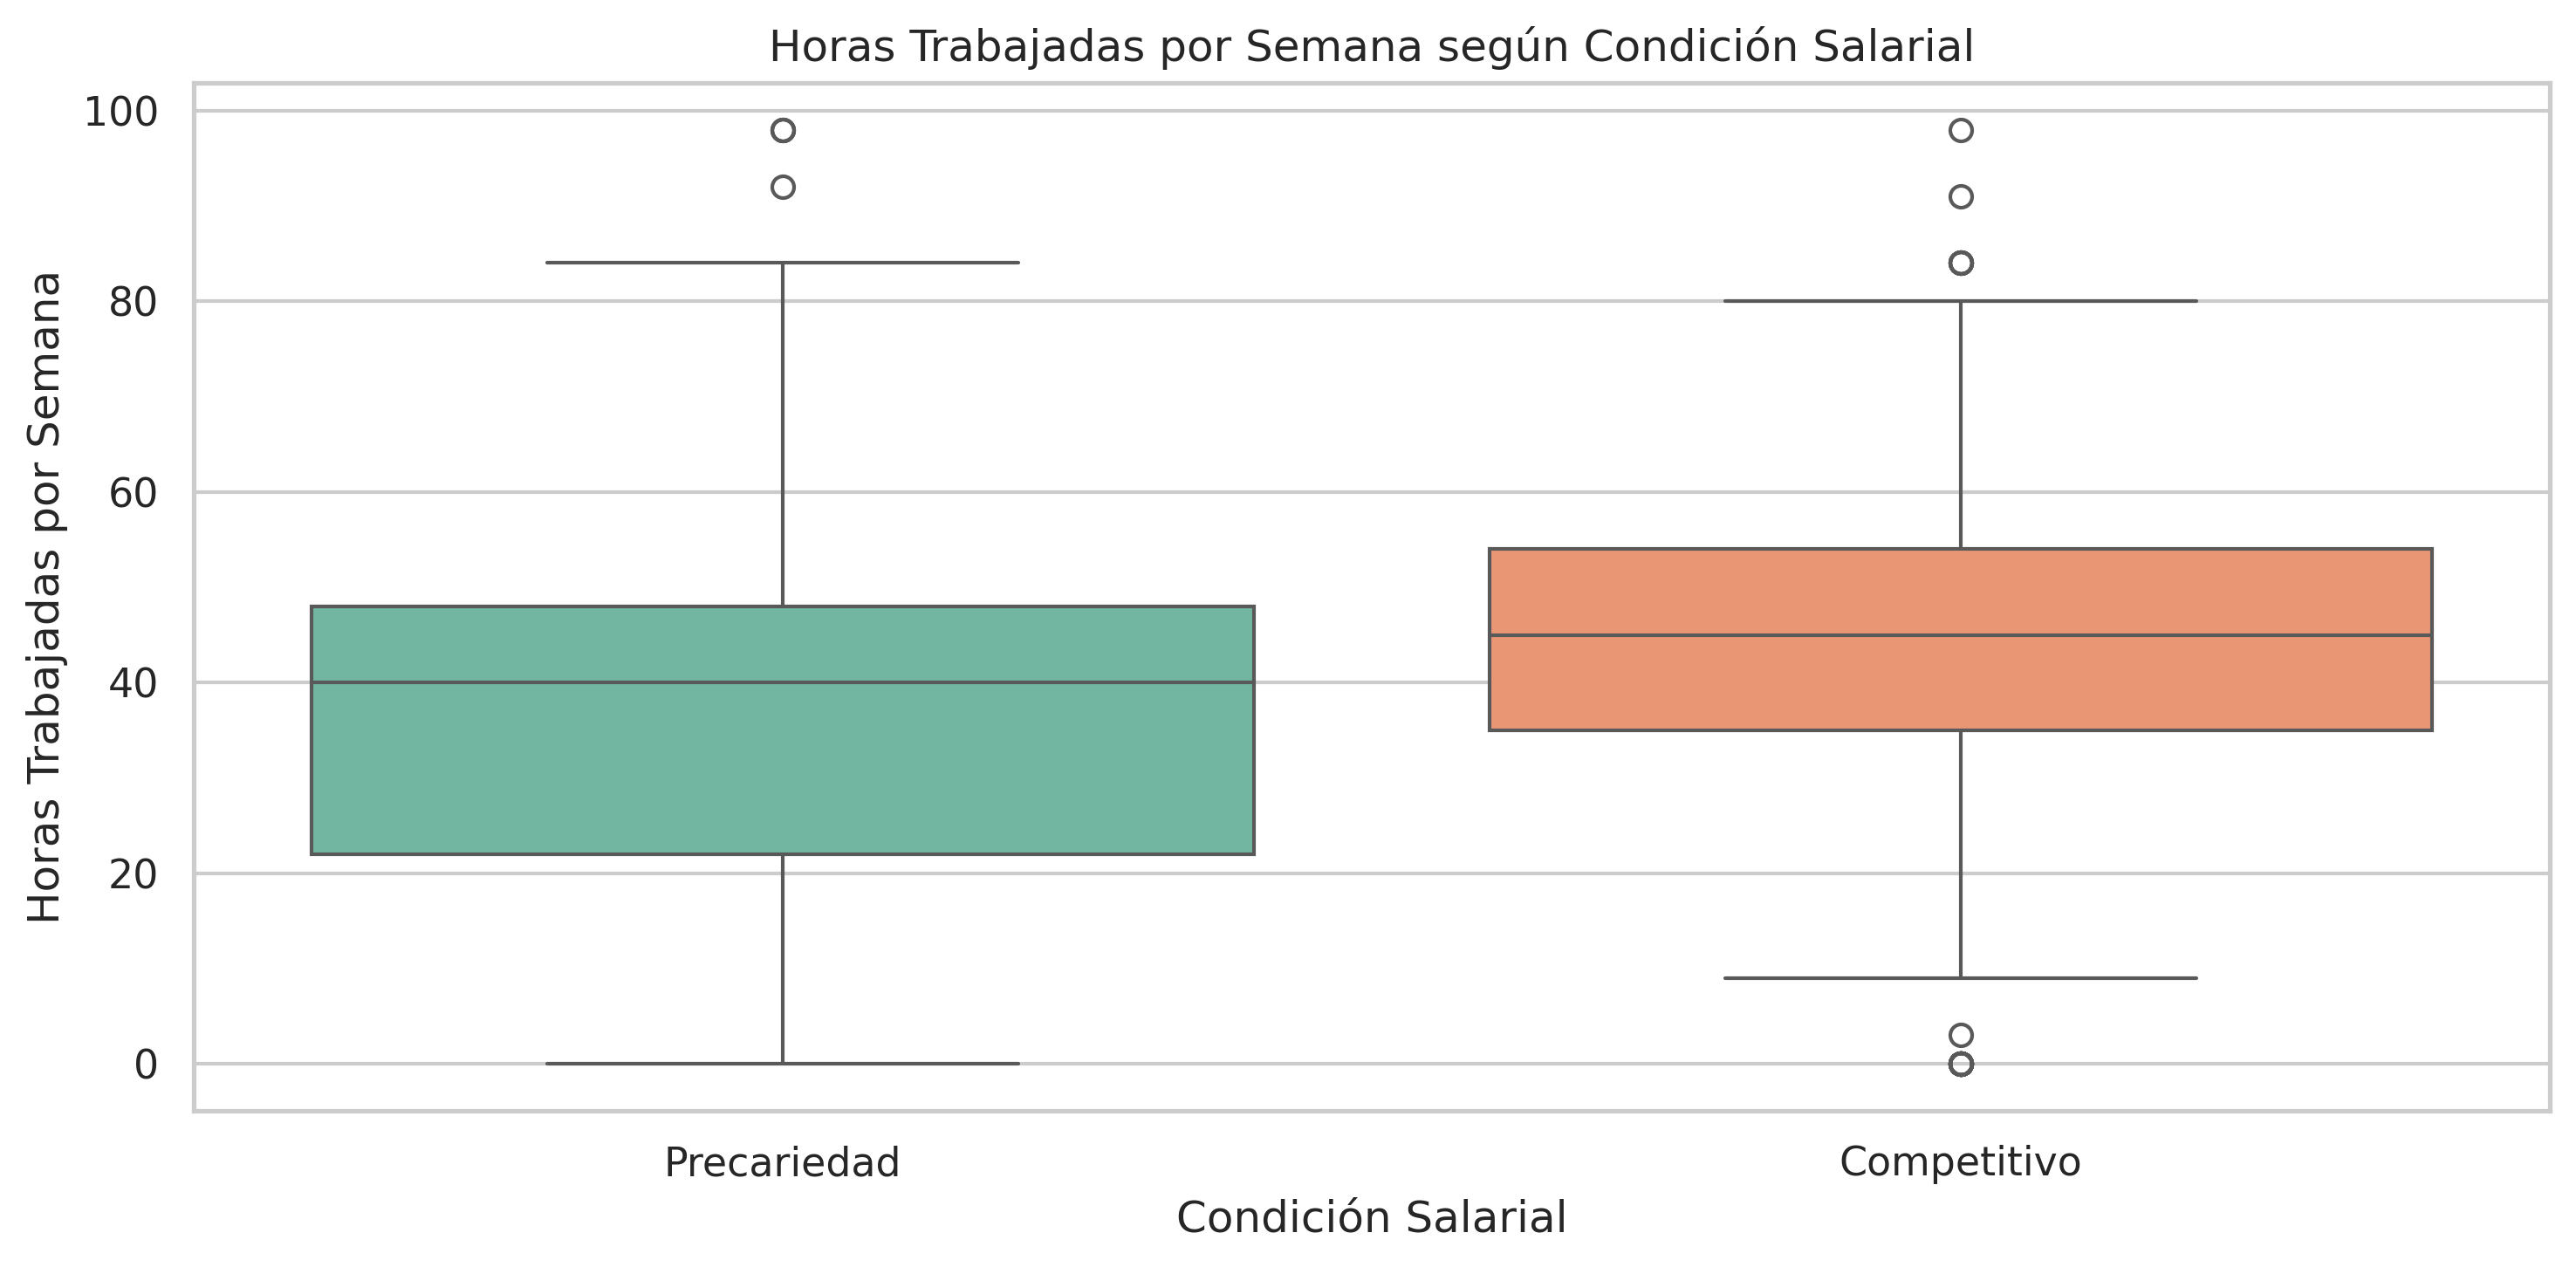

**Interpretación:** El gráfico de caja muestra la dispersión de horas trabajadas. El grupo clasificado en precariedad tiene una mediana de 40.0 horas semanales, frente a 45.0 horas en el grupo competitivo. Se observan posibles jornadas atípicas y una concentración en torno a la jornada laboral estándar.

In [16]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_plot, x='target_etiq', y='hrs_trabajo', hue='target_etiq', palette='Set2', legend=False)
plt.title('Horas Trabajadas por Semana según Condición Salarial')
plt.xlabel('Condición Salarial')
plt.ylabel('Horas Trabajadas por Semana')
plt.tight_layout()
plt.savefig('figuras_eda/fig_5_3_hrs_trabajo.png')
plt.show()

mediana_hrs_prec = df_plot[df_plot['target_etiq'] == 'Precariedad']['hrs_trabajo'].median()
mediana_hrs_comp = df_plot[df_plot['target_etiq'] == 'Competitivo']['hrs_trabajo'].median()

display(Markdown(f"**Interpretación:** El gráfico de caja muestra la dispersión de horas trabajadas. El grupo clasificado en precariedad tiene una mediana de {mediana_hrs_prec} horas semanales, frente a {mediana_hrs_comp} horas en el grupo competitivo. Se observan posibles jornadas atípicas y una concentración en torno a la jornada laboral estándar."))

### Tiene jefe o superior
Relevancia de la subordinación directa en el lugar de trabajo.

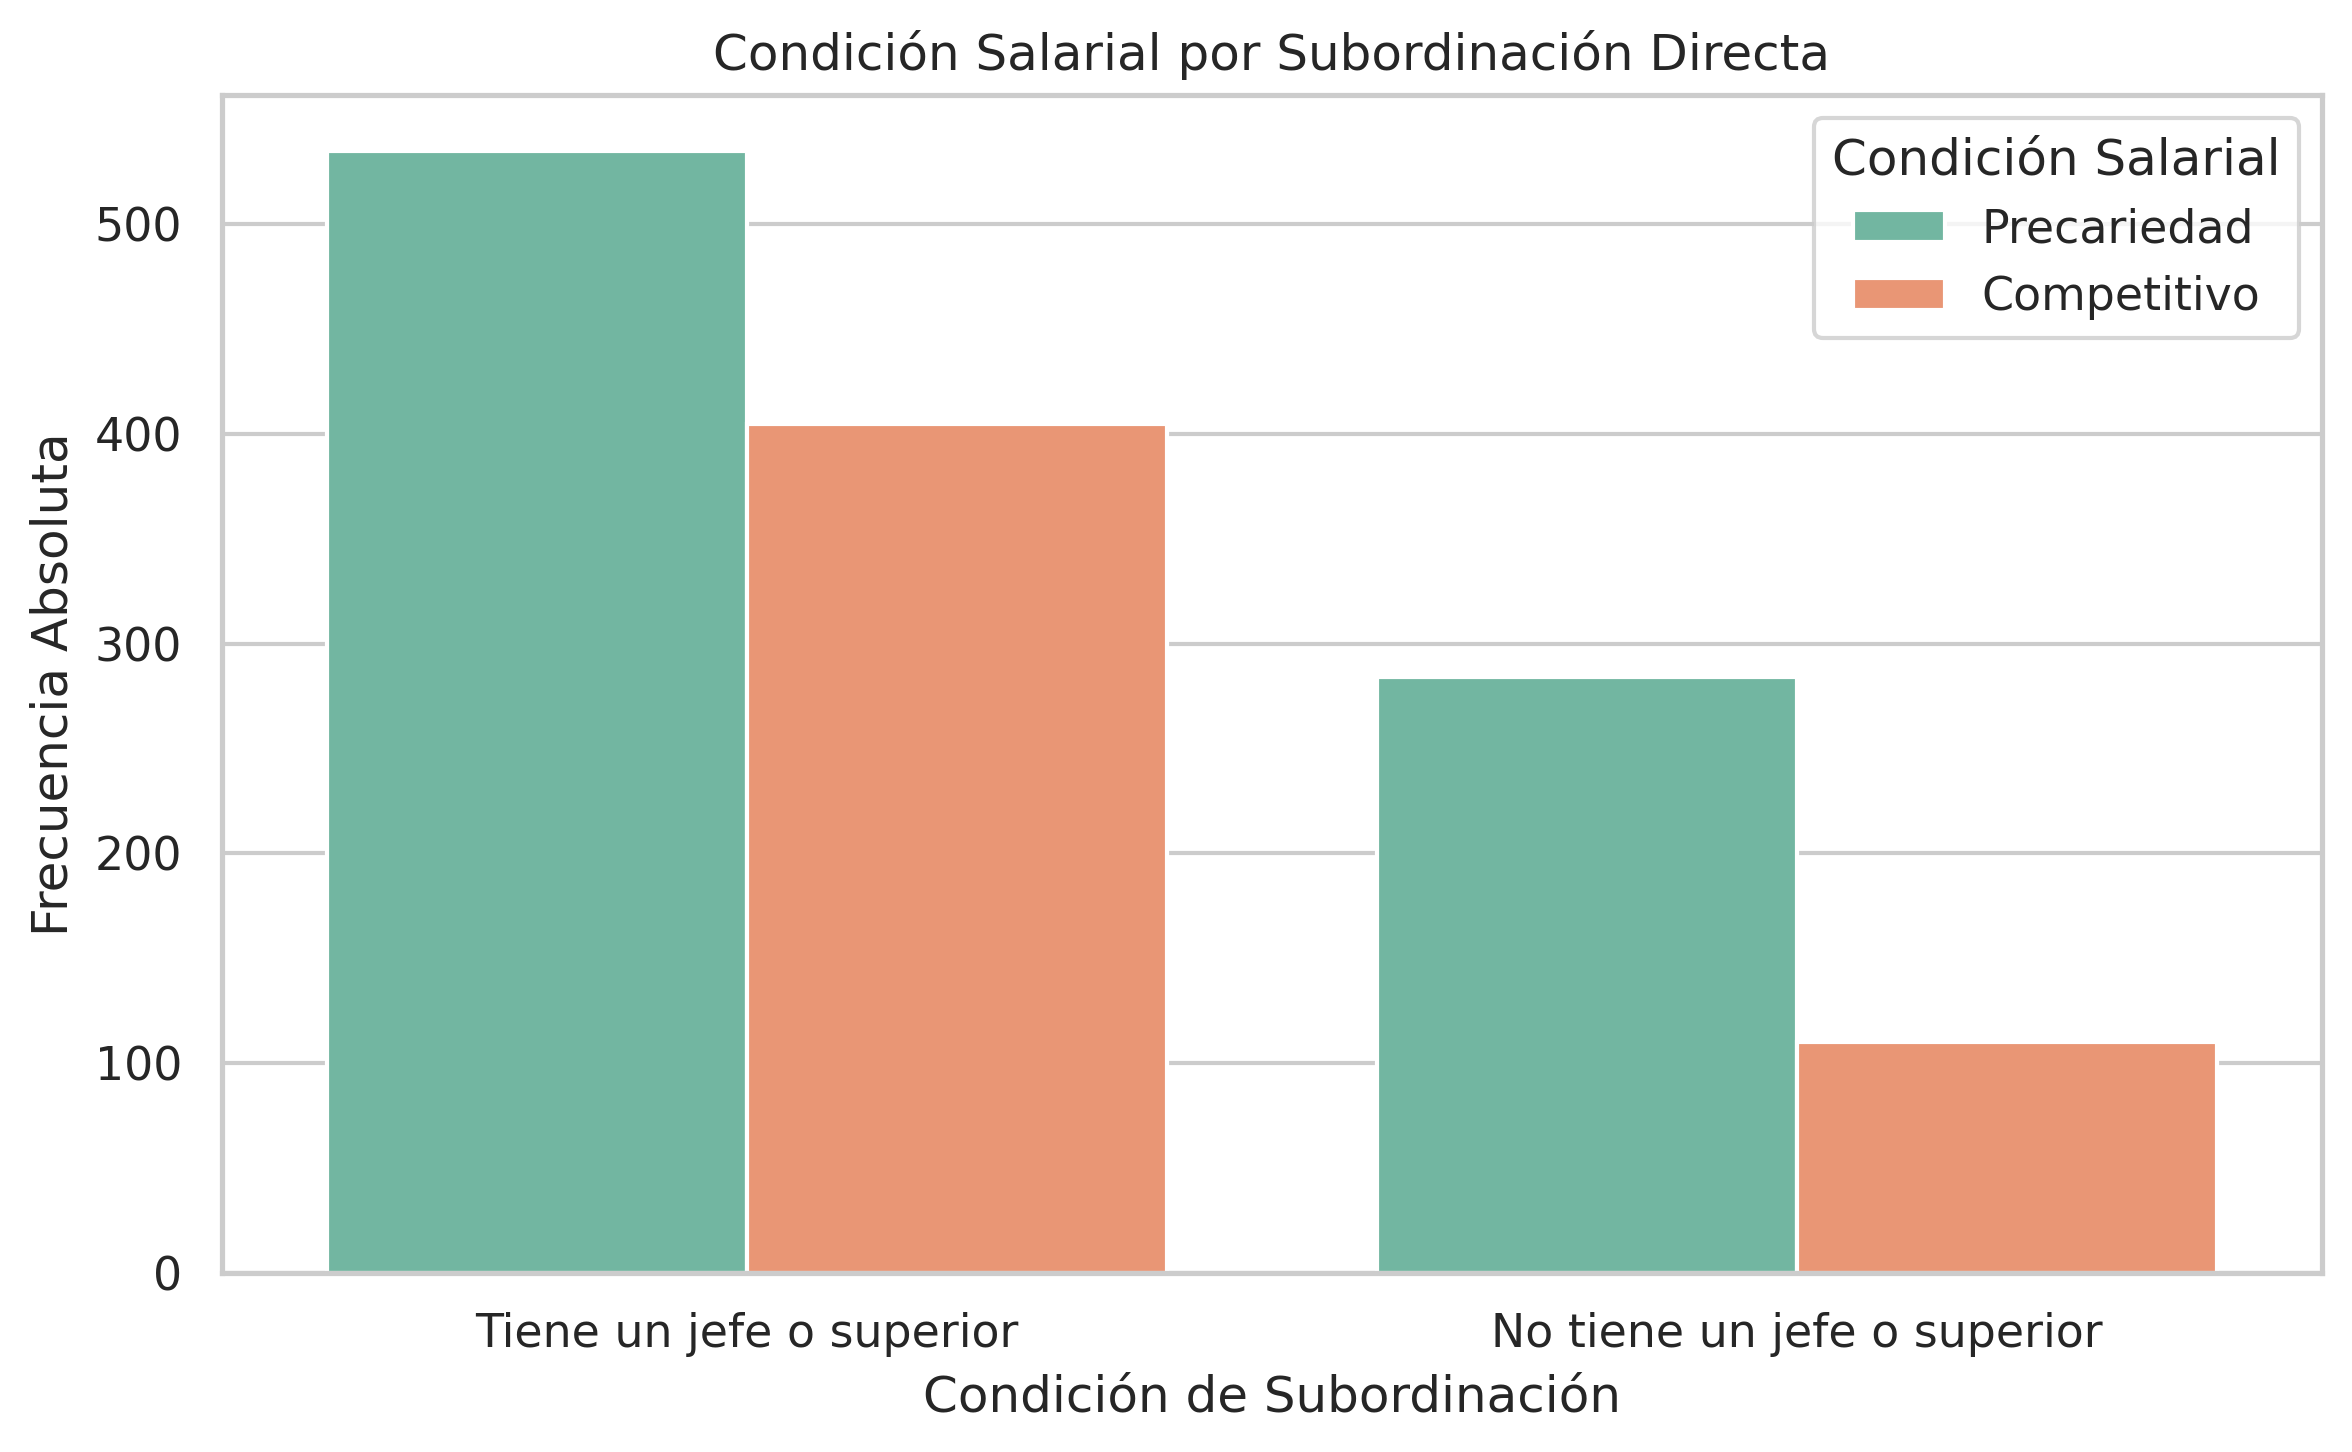

**Interpretación:** Esta figura evalúa si tener un superior se asocia descriptivamente de manera diferencial con los niveles salariales. La comparación estructural ayuda a matizar el análisis realizado sobre el tipo de empleado y la formalidad.

In [17]:
df_plot['jefe_etiq'] = df_plot['tiene_jefe'].map(map_tiene_jefe)

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_plot, x='jefe_etiq', hue='target_etiq', palette='Set2')
plt.title('Condición Salarial por Subordinación Directa')
plt.xlabel('Condición de Subordinación')
plt.ylabel('Frecuencia Absoluta')
plt.legend(title='Condición Salarial')
plt.tight_layout()
plt.savefig('figuras_eda/fig_5_3_tiene_jefe.png')
plt.show()

display(Markdown("**Interpretación:** Esta figura evalúa si tener un superior se asocia descriptivamente de manera diferencial con los niveles salariales. La comparación estructural ayuda a matizar el análisis realizado sobre el tipo de empleado y la formalidad."))

### Ingreso
Comportamiento descriptivo de la variable original.

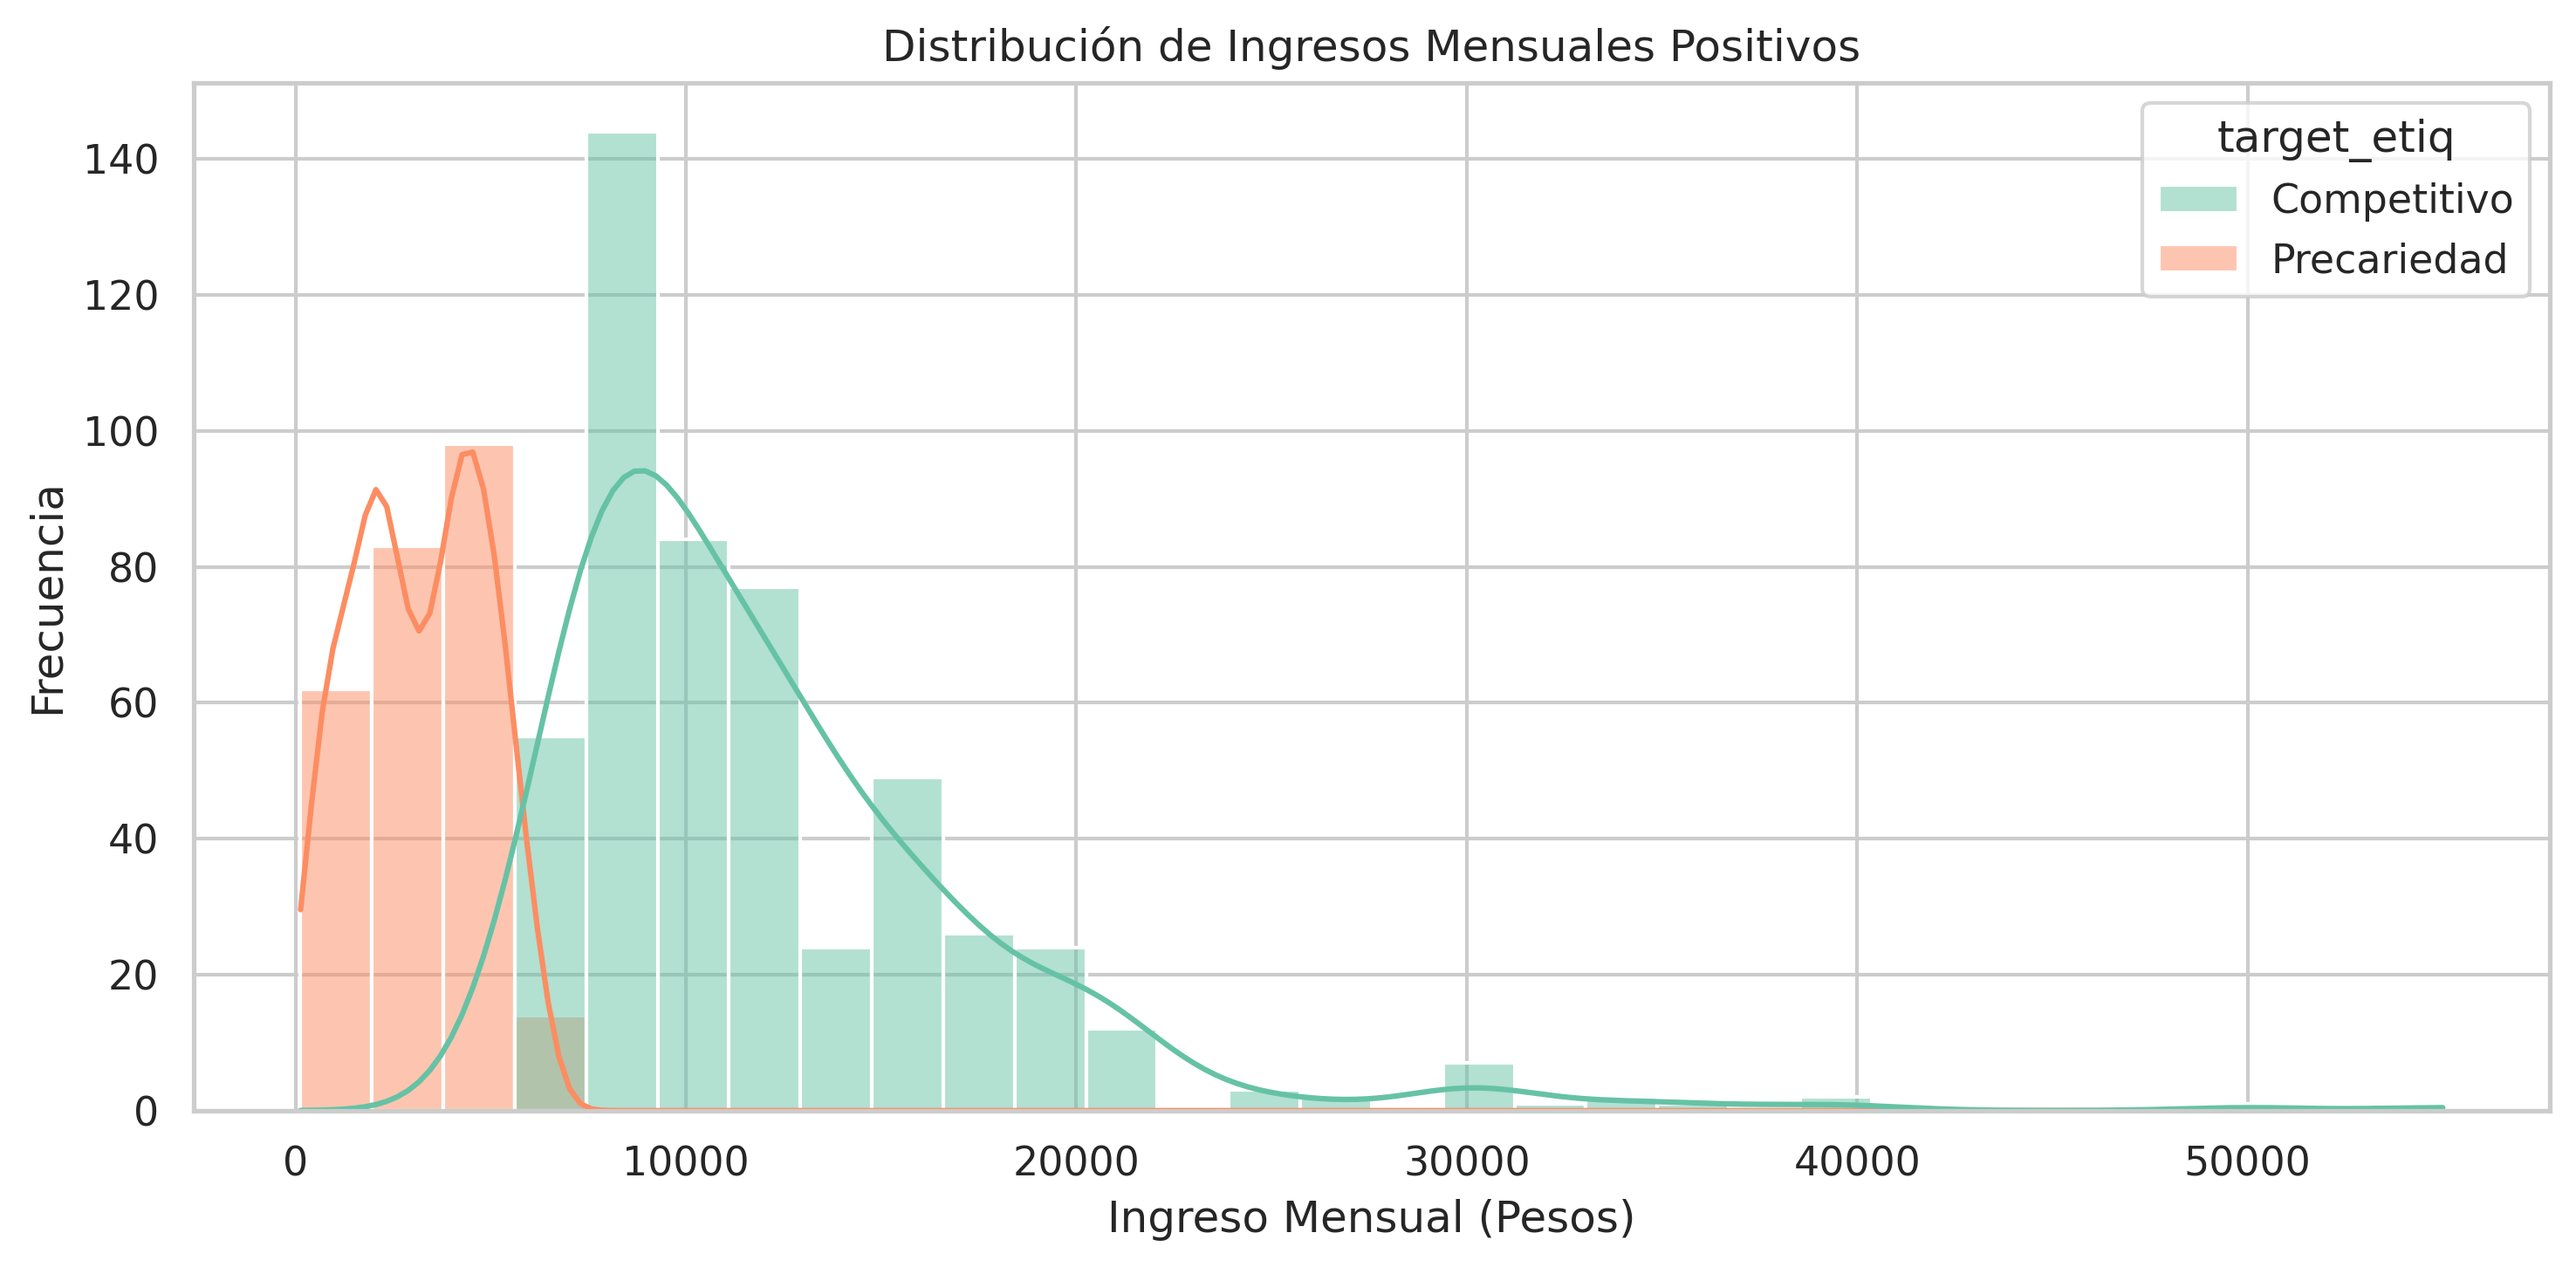

**Interpretación:** La figura representa el histograma y estimación de densidad para los ingresos mayores a cero. Refleja la fuerte asimetría positiva característica de las variables de ingreso y visualiza claramente el punto de corte (percentil 33) establecido para clasificar la precariedad salarial en el grupo competitivo y precario.

In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_plot[df_plot['ingreso'] > 0], x='ingreso', hue='target_etiq', bins=30, kde=True, palette='Set2')
plt.title('Distribución de Ingresos Mensuales Positivos')
plt.xlabel('Ingreso Mensual (Pesos)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('figuras_eda/fig_5_3_ingreso.png')
plt.show()

display(Markdown("**Interpretación:** La figura representa el histograma y estimación de densidad para los ingresos mayores a cero. Refleja la fuerte asimetría positiva característica de las variables de ingreso y visualiza claramente el punto de corte (percentil 33) establecido para clasificar la precariedad salarial en el grupo competitivo y precario."))

## 5.4 Análisis bivariado, matrices de correlación y hallazgos

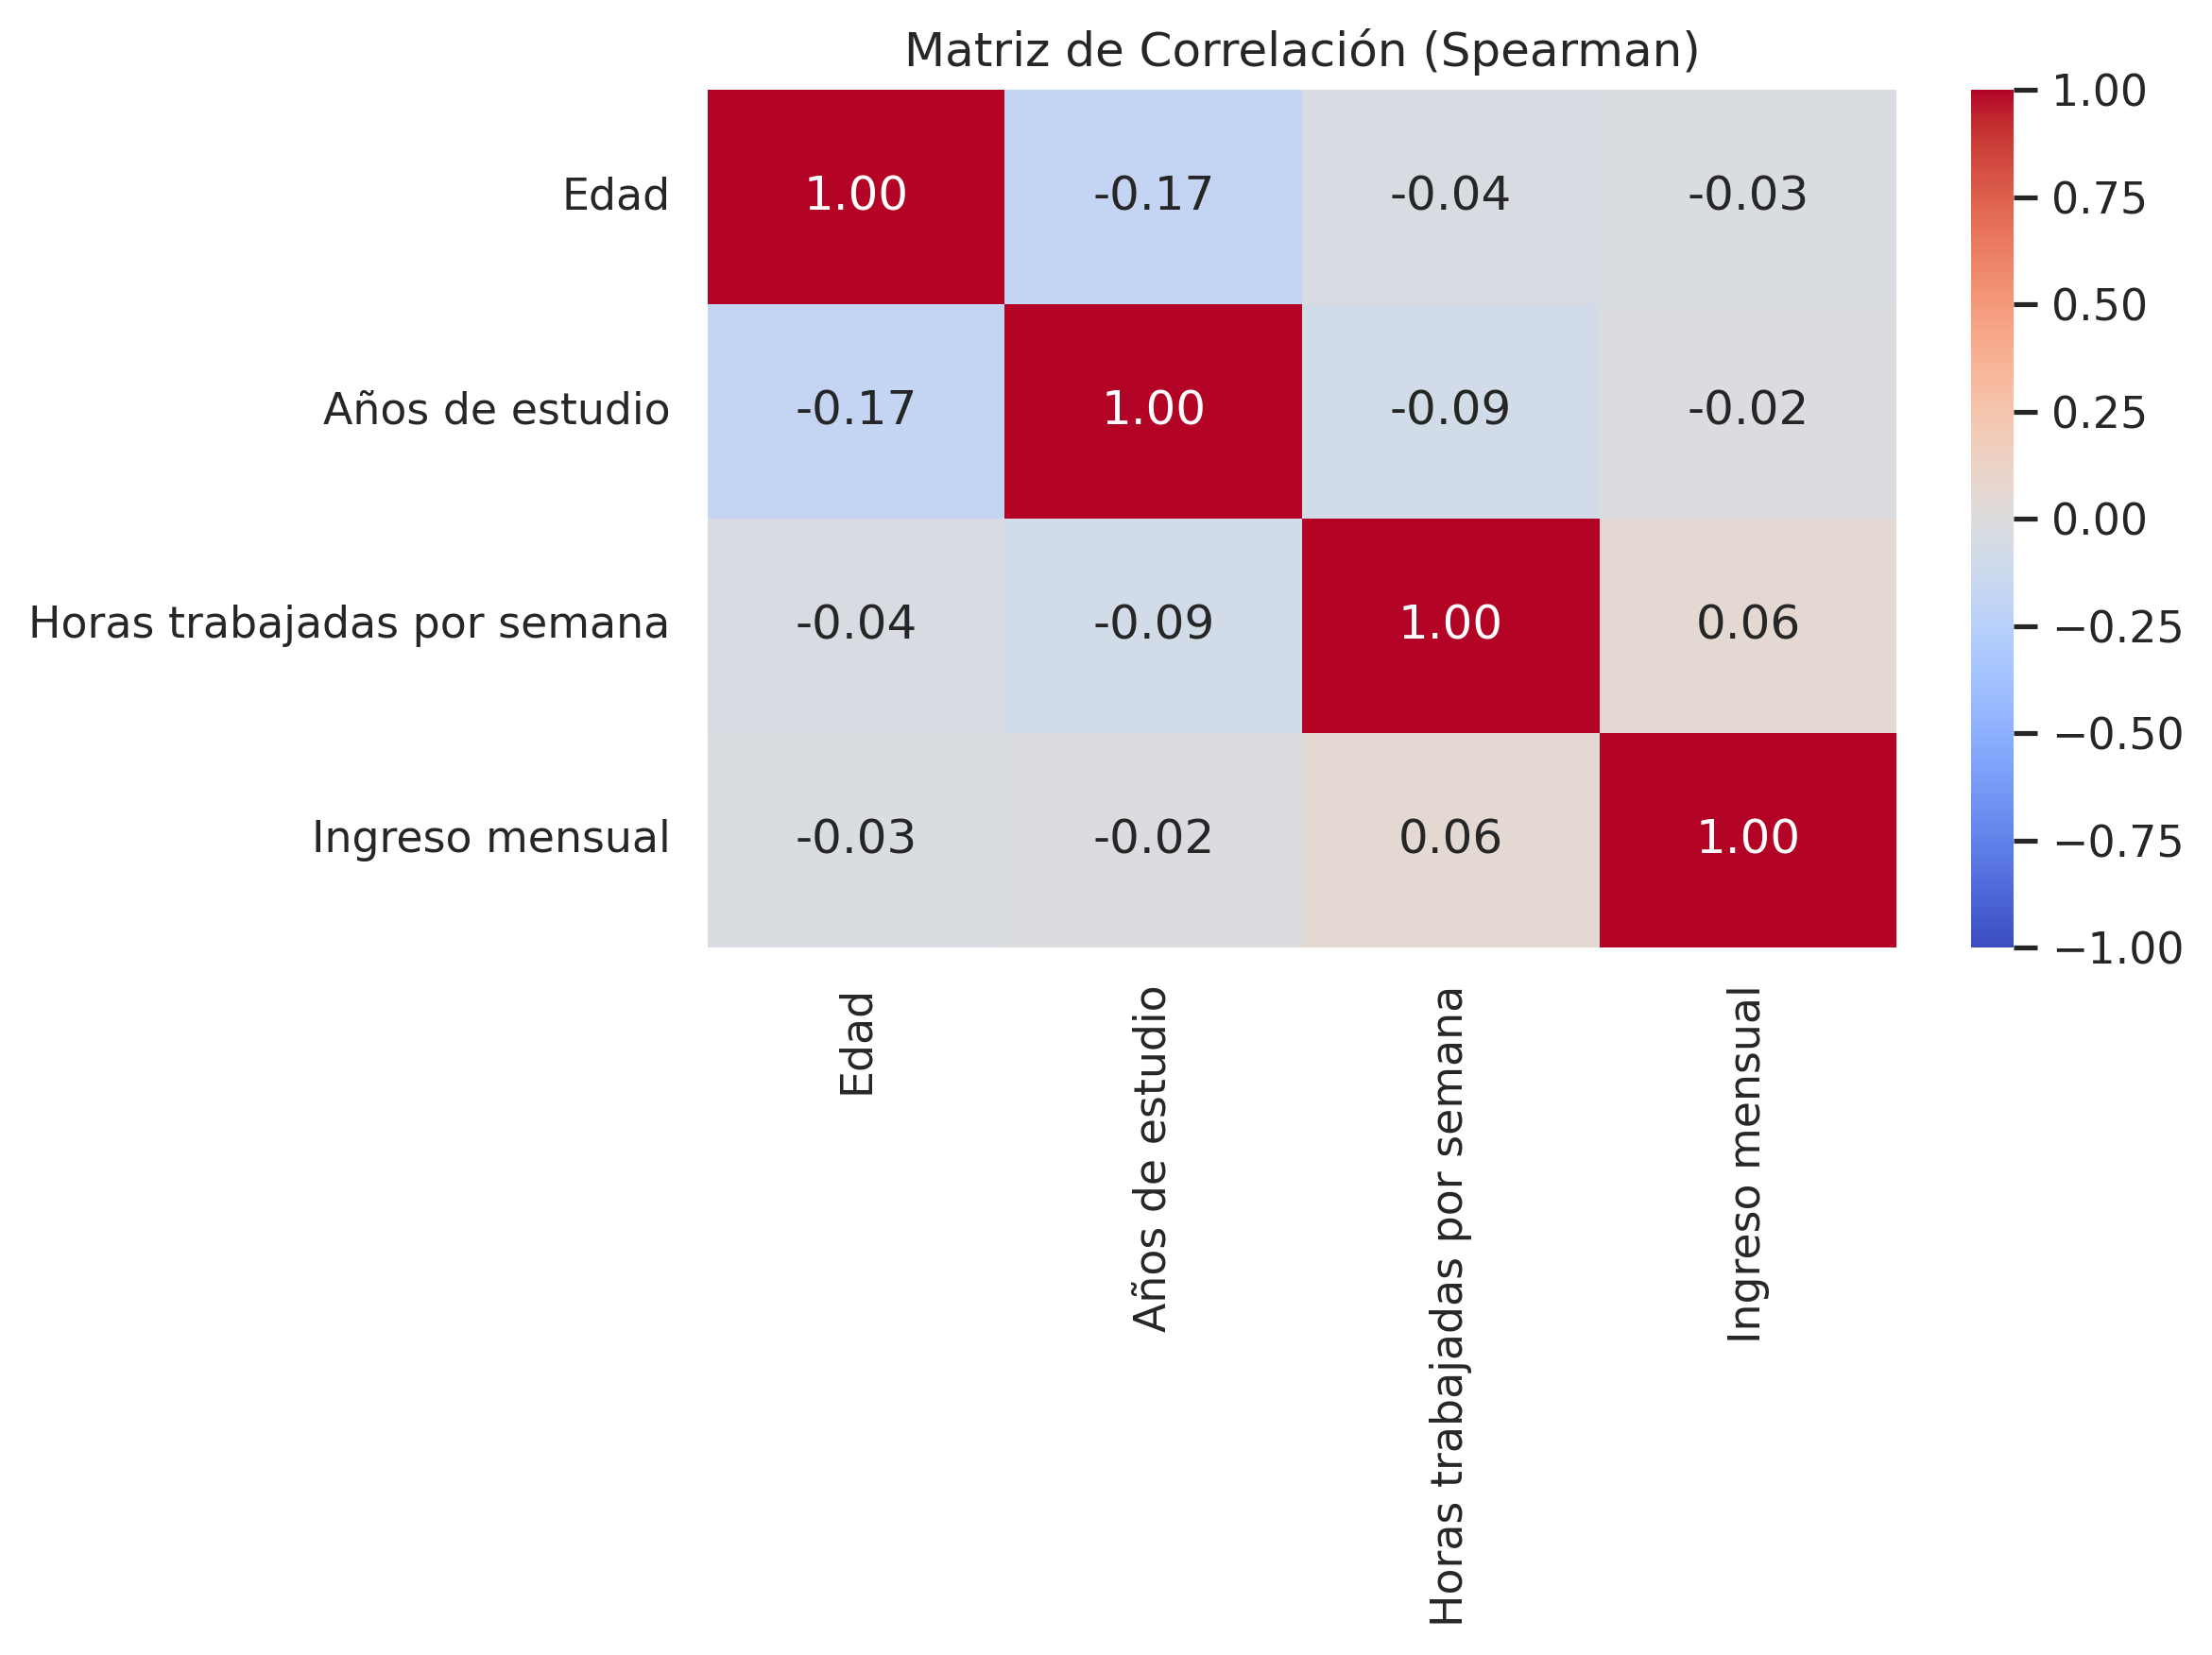

**Interpretación:** La matriz de correlación expone las relaciones monotónicas (Spearman) entre las variables métricas. Se seleccionó este método debido a la naturaleza asimétrica del ingreso y la presencia de casos nulos (previamente manejados). Los coeficientes permiten identificar si existe asociación descriptiva (por ejemplo, entre los años de escolaridad y el ingreso reportado), sin implicar causalidad.

In [5]:
# Variables cuantitativas para correlación
cuantitativas = ['edad', 'anios_estudio', 'hrs_trabajo', 'ingreso']
corr_df = df[cuantitativas].rename(columns={
    'edad': 'Edad',
    'anios_estudio': 'Años de estudio',
    'hrs_trabajo': 'Horas trabajadas por semana',
    'ingreso': 'Ingreso mensual'
})

# Matriz de correlación de Spearman (más robusta para ingresos con asimetría y valores extremos)
matriz_corr = corr_df.corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Matriz de Correlación (Spearman)')
plt.tight_layout()
plt.savefig('figuras_eda/fig_5_4_matriz_correlacion.png')
plt.show()

display(Markdown("**Interpretación:** La matriz de correlación expone las relaciones monotónicas (Spearman) entre las variables métricas. Se seleccionó este método debido a la naturaleza asimétrica del ingreso y la presencia de casos nulos (previamente manejados). Los coeficientes permiten identificar si existe asociación descriptiva (por ejemplo, entre los años de escolaridad y el ingreso reportado), sin implicar causalidad."))


## Tablas Descriptivas de Resumen

A continuación se presentan las tablas consolidadas que resumen la estructura de la muestra, los valores faltantes, las estadísticas descriptivas y las proporciones de precariedad por variable categórica.

In [19]:
# 1 y 2. Tabla de valores faltantes
tabla_faltantes = df.isnull().sum().reset_index()
tabla_faltantes.columns = ['Variable', 'Valores Faltantes']
tabla_faltantes['Porcentaje (%)'] = (tabla_faltantes['Valores Faltantes'] / len(df)) * 100
display(Markdown("### Tabla 1. Valores faltantes por variable"))
display(tabla_faltantes)

# 3. Tabla de distribución de target_precariedad
tabla_target = df_plot['target_etiq'].value_counts().reset_index()
tabla_target.columns = ['Condición Salarial', 'Frecuencia']
tabla_target['Porcentaje (%)'] = (tabla_target['Frecuencia'] / len(df_plot)) * 100
display(Markdown("### Tabla 2. Distribución de la variable objetivo (target_precariedad)"))
display(tabla_target)

# 4. Tabla descriptiva de variables cuantitativas
tabla_cuant = df_plot[['edad', 'anios_estudio', 'hrs_trabajo', 'ingreso']].describe().T
display(Markdown("### Tabla 3. Estadísticas descriptivas de variables cuantitativas"))
display(tabla_cuant)

# 5 y 6. Tablas de proporción de precariedad por variables categóricas clave

# Sexo
tabla_sexo = pd.crosstab(df_plot['sexo_etiq'], df_plot['target_etiq'], margins=True)
tabla_sexo_pct = pd.crosstab(df_plot['sexo_etiq'], df_plot['target_etiq'], normalize='index') * 100
display(Markdown("### Tabla 4. Frecuencia y Proporción de precariedad por Sexo"))
display(tabla_sexo)
display(tabla_sexo_pct)

# Estrato
tabla_estrato_pct = pd.crosstab(df_plot['estrato_etiq'], df_plot['target_etiq'], normalize='index') * 100
display(Markdown("### Tabla 5. Proporción de precariedad por Estrato (%)"))
display(tabla_estrato_pct)

# Formalidad Laboral
tabla_formal_pct = pd.crosstab(df_plot['formal_etiq'], df_plot['target_etiq'], normalize='index') * 100
display(Markdown("### Tabla 6. Proporción de precariedad por Formalidad Laboral (%)"))
display(tabla_formal_pct)

# Tipo de Empleado
tabla_emp_pct = pd.crosstab(df_plot['empleado_etiq'], df_plot['target_etiq'], normalize='index') * 100
display(Markdown("### Tabla 7. Proporción de precariedad por Tipo de Empleado (%)"))
display(tabla_emp_pct)

### Tabla 1. Valores faltantes por variable

,Variable,Valores Faltantes,Porcentaje (%)
0,mpio,0,0.00000
1,estrato,0,0.00000
2,sexo,0,0.00000
3,edad,0,0.00000
4,edo_civil,0,0.00000
5,pea_si_no,0,0.00000
6,tipo_empleado,0,0.00000
7,tipo_empresa,0,0.00000
8,anios_estudio,0,0.00000
9,hrs_trabajo,0,0.00000


### Tabla 2. Distribución de la variable objetivo (target_precariedad)

,Condición Salarial,Frecuencia,Porcentaje (%)
0,Precariedad,848,62.215701
1,Competitivo,515,37.784299


### Tabla 3. Estadísticas descriptivas de variables cuantitativas

...

target_etiq,Competitivo,Precariedad
estrato_etiq,,
Estrato alto,44.029851,55.970149
Estrato bajo,41.203704,58.796296
Estrato medio alto,34.435262,65.564738
Estrato medio bajo,37.230769,62.769231


### Tabla 6. Proporción de precariedad por Formalidad Laboral (%)

target_etiq,Competitivo,Precariedad
formal_etiq,,
Empleo formal,45.670628,54.329372
Empleo informal,33.020134,66.979866
No aplica,0.000000,100.000000


### Tabla 7. Proporción de precariedad por Tipo de Empleado (%)

target_etiq,Competitivo,Precariedad
empleado_etiq,,
Empleadores,42.105263,57.894737
No aplica,0.000000,100.000000
Subordinados y remunerados,42.948038,57.051962
Trabajadores por cuenta propia,24.761905,75.238095


# Conclusiones del análisis exploratorio de datos

En esta etapa descriptiva, se exploraron las características sociodemográficas y laborales de la población económicamente activa en Oaxaca de Juárez. Se construyó el indicador `target_precariedad` de manera operacional, demostrando las distribuciones salariales y las concentraciones poblacionales en condiciones de precariedad. Estos hallazgos fundamentarán la selección de variables para las etapas posteriores de modelado.

### Síntesis final

1. **Variables con asociaciones descriptivas más relevantes:** `sexo`, `emp_formal_inf` (formalidad laboral), `estrato` y `anios_estudio`.
2. **Hallazgos principales:**
   - El 62.2% de la muestra se clasifica en precariedad salarial (ingreso <= $6,000.00).
   - Existe una mayor proporción de mujeres en situación de precariedad (68.7%) comparado con los hombres (56.8%).
   - El empleo informal concentra una alta proporción de precariedad salarial (67.0%).
   - Mayores niveles de escolaridad y pertenecer a estratos socioeconómicos más altos muestran una asociación descriptiva con menores proporciones de precariedad.
3. **Variables a priorizar en el modelado:** `sexo`, `emp_formal_inf`, `estrato`, `anios_estudio`, y `edad`.
4. **Limitaciones y advertencias:** El análisis es estrictamente descriptivo e identifica asociaciones, no causalidad. La variable objetivo es sintética y depende operativamente del percentil 33 de los ingresos positivos reportados, por lo que cualquier interpretación debe remitirse a esta definición metodológica.

## Exportación de Figuras
Celda utilitaria para empaquetar y descargar todas las figuras generadas durante el Análisis Exploratorio de Datos.

In [20]:
import shutil
from google.colab import files

# Nombre del archivo ZIP de salida (sin la extensión)
nombre_zip = 'figuras_eda_export'

# Comprimir el directorio 'figuras_eda'
shutil.make_archive(nombre_zip, 'zip', 'figuras_eda')

print(f"Directorio 'figuras_eda' comprimido exitosamente como {nombre_zip}.zip")

# Iniciar la descarga del archivo ZIP
files.download(f"{nombre_zip}.zip")


Directorio 'figuras_eda' comprimido exitosamente como figuras_eda_export.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Estadísticos Descriptivos Robustos:


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
edad,1363.0,41.898753,14.262898,14.0,31.0,41.0,52.0,83.0,0.310352,-0.568791
anios_estudio,1363.0,12.015407,6.034207,0.0,9.0,12.0,17.0,99.0,6.408919,93.283569
hrs_trabajo,1363.0,39.054292,18.787590,0.0,28.0,40.0,48.0,98.0,-0.220955,-0.012848
ingreso,1363.0,5239.289068,6713.726319,0.0,0.0,2150.0,8600.0,55000.0,1.782995,5.377972


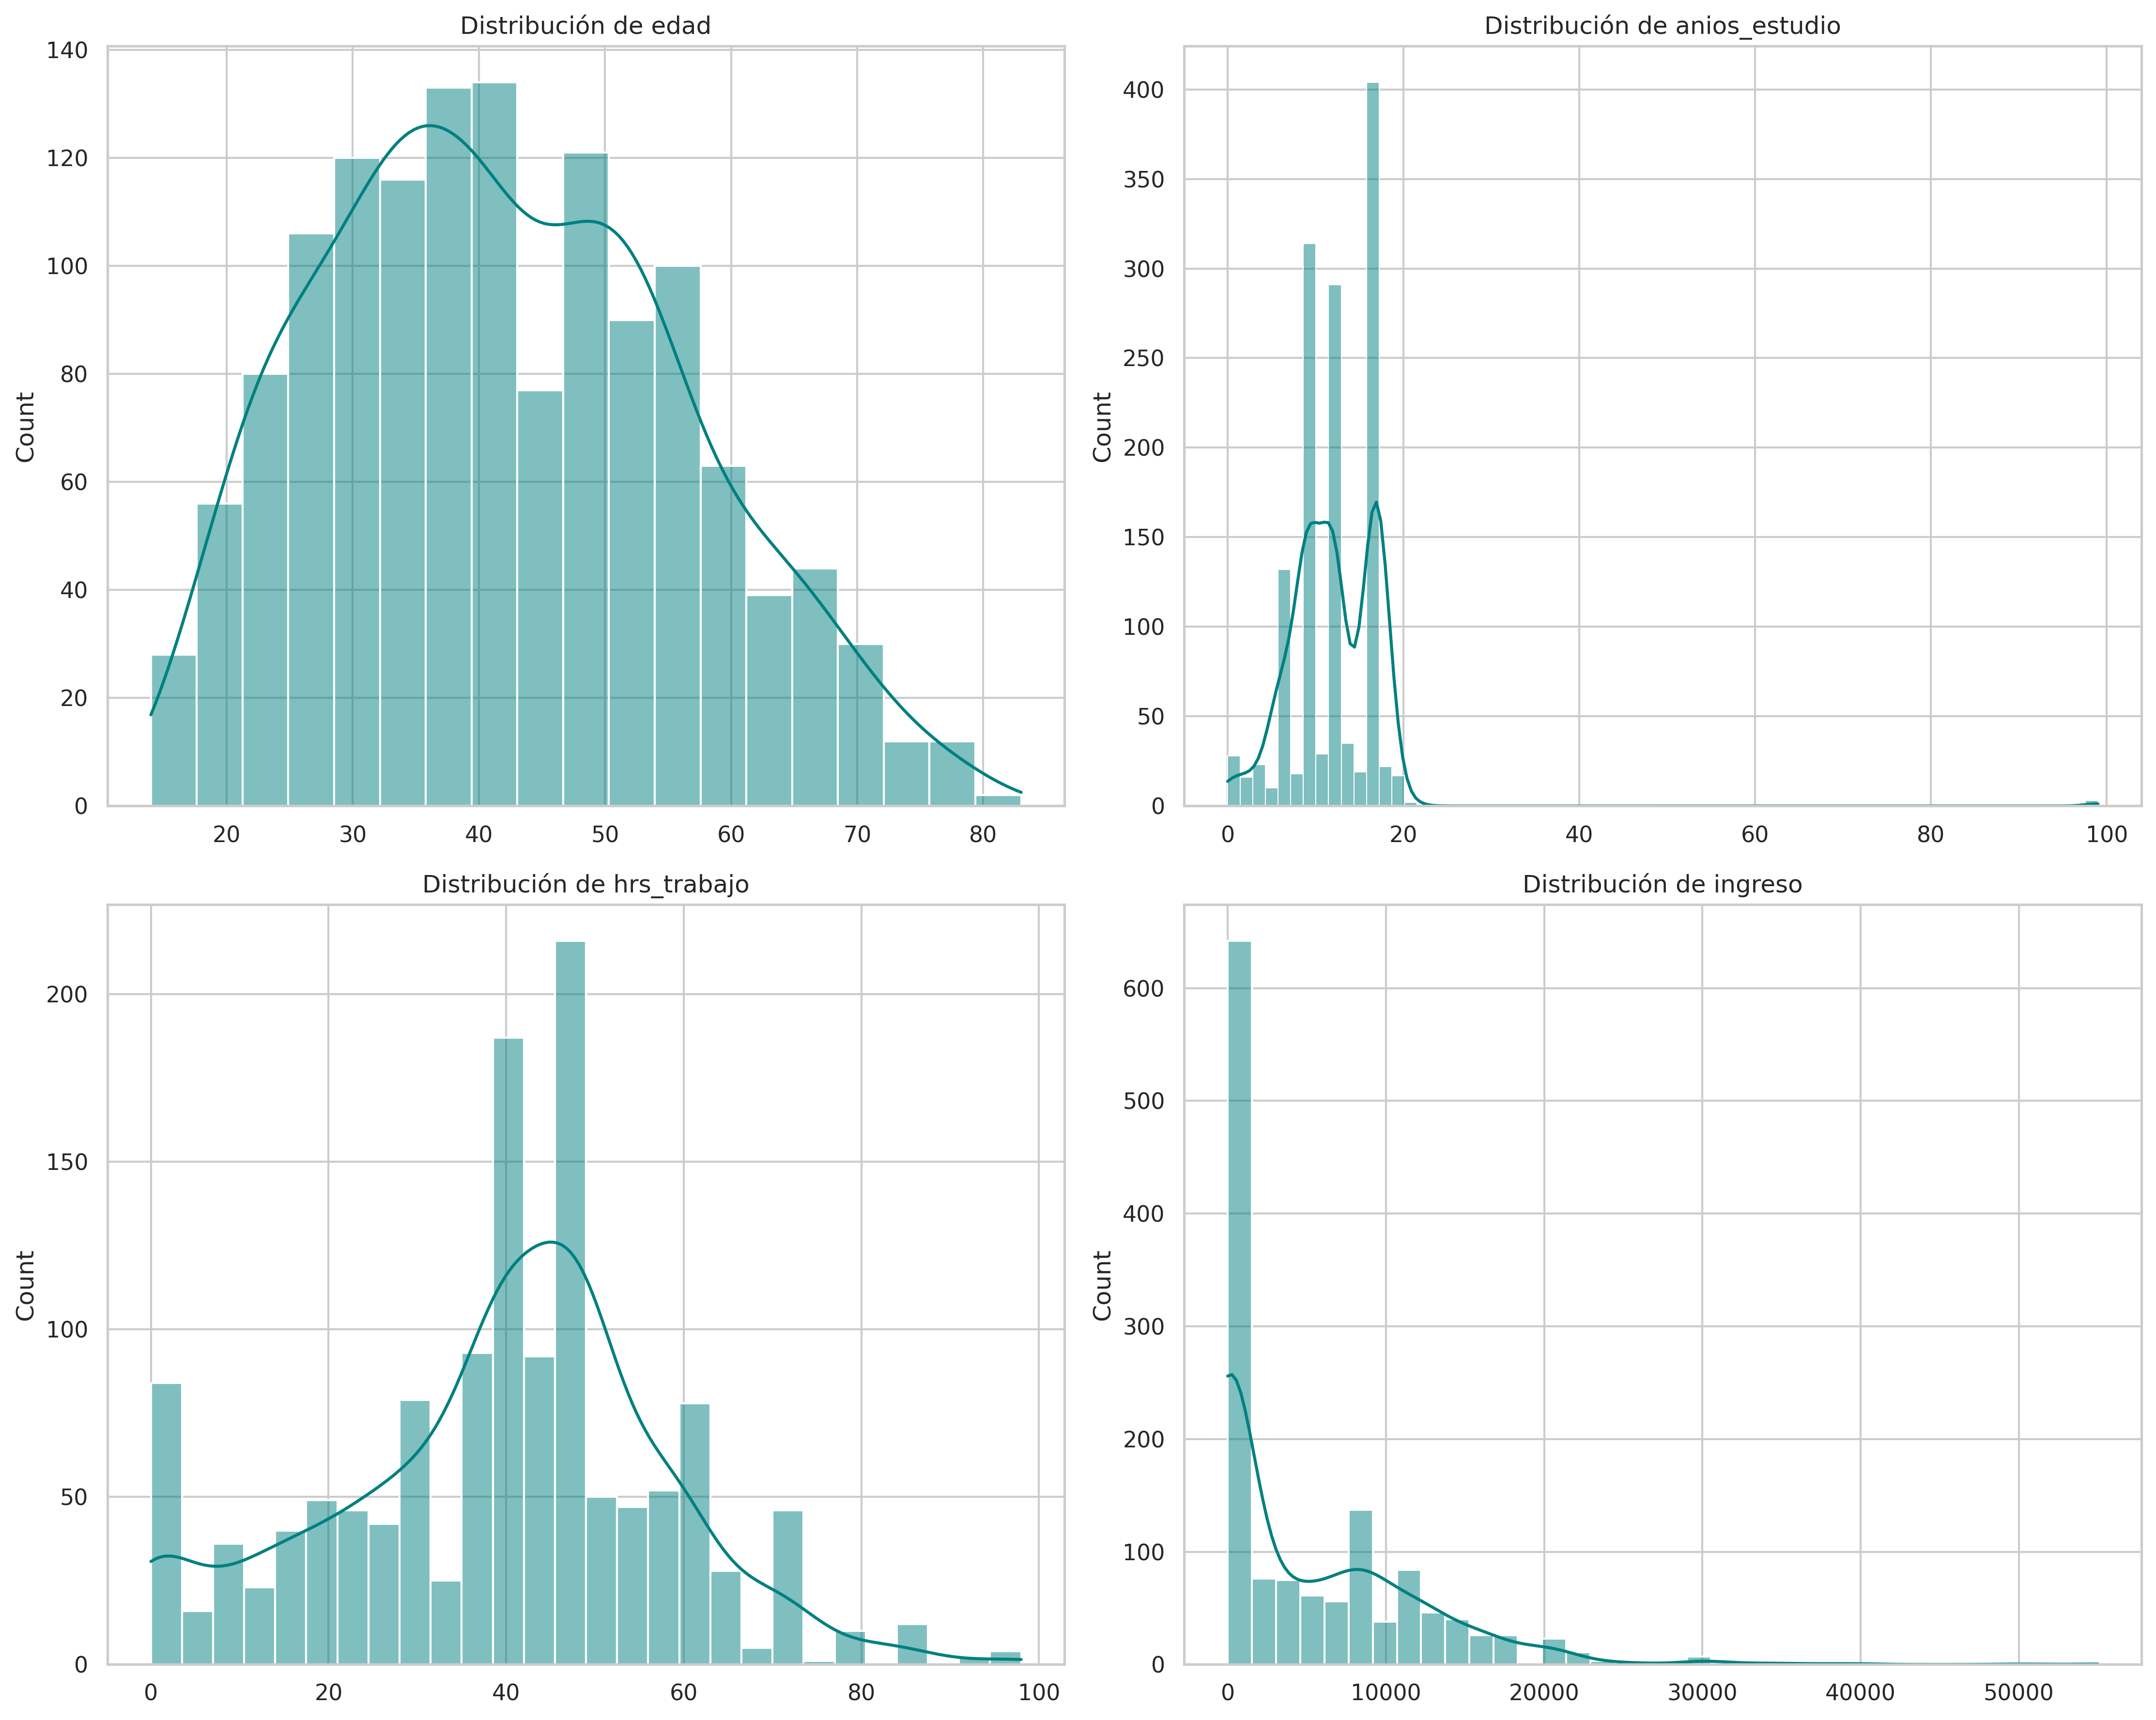

In [21]:
num_vars = ['edad', 'anios_estudio', 'hrs_trabajo', 'ingreso']
stats_num = df[num_vars].describe().T
stats_num['skewness'] = df[num_vars].skew()
stats_num['kurtosis'] = df[num_vars].kurt()

print("Estadísticos Descriptivos Robustos:")
display(stats_num)

# Visualización de distribuciones
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

Hallazgo descriptivo:

Ingreso: Presenta un sesgo positivo extremo (Skewness ≈ 1.78), con una concentración masiva en los niveles bajos de la escala salarial.
Años de Estudio: Distribución multimodal con picos en 9, 12 y 17 años, reflejando hitos educativos (secundaria, preparatoria y licenciatura).
Horas de Trabajo: Pico pronunciado en las 40-48 horas, pero con una dispersión notable hacia jornadas extendidas (>60 horas).
Interpretación estadística: Dado el alto sesgo y la curtosis del ingreso (5.37), la media aritmética no es una medida de tendencia central representativa. Los resultados del modelado deben basarse en la mediana, ya que la media está artificialmente inflada por un pequeño grupo de altos ingresos.

Implicación para la investigación: La precariedad no es un fenómeno marginal; la distribución del ingreso muestra que la mayoría de la población en Oaxaca de Juárez sobrevive en el primer tercio de la distribución salarial, validando el uso del percentil 33 como punto de corte para target_precariedad.